# TESTING - Baseline search algorithm

In [1]:
METHOD = "BASELINE"

In [2]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [3]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[55]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[10:36:10:221119]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_1.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[10:36:10:403132]:[Warning]:[Sim

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


es not contain semantic annotations : activeSemanticSceneID_ = 0
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D()

In [4]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
num_free_cells = len(grid_free_cells)

In [5]:
starting_grid_positions = [[3, 28], [4, 25], [6, 27], [4, 22], [6, 7], [12, 11], [11, 24], [4, 14], [12, 4], [11, 3], [11, 29], [3, 26], [12, 6], [11, 22], [10, 27], [6, 25], [12, 4], [8, 17], [11, 22], [7, 26], [11, 28], [11, 3], [4, 12], [4, 14], [7, 28], [6, 16], [13, 13], [3, 25], [4, 26], [8, 14], [4, 8], [3, 8], [7, 14], [6, 5], [10, 15], [11, 15], [4, 9], [13, 23], [11, 23], [11, 24], [3, 17], [6, 19], [9, 15], [3, 7], [3, 27], [6, 13], [11, 20], [6, 14], [5, 20], [13, 10], [6, 5], [12, 13], [3, 6], [12, 11], [5, 6], [3, 20], [6, 7], [9, 18], [11, 7], [4, 24], [10, 24], [5, 25], [5, 17], [11, 26], [8, 19], [3, 24], [11, 19], [7, 17], [10, 27], [3, 8], [10, 26], [9, 14], [12, 6], [3, 26], [9, 16], [10, 24], [12, 13], [3, 18], [6, 24], [3, 15], [5, 7], [12, 12], [12, 3], [11, 16], [3, 19], [11, 13], [10, 18], [4, 27], [13, 5], [11, 16], [6, 26], [5, 8], [10, 19], [11, 23], [9, 17], [12, 11], [6, 14], [6, 17], [7, 26], [3, 25], ]
starting_orientations = [180, 180, 270, 180, 270, 90, 90, 90, 90, 270, 0, 180, 90, 90, 0, 90, 90, 180, 90, 270, 90, 90, 90, 0, 90, 180, 270, 90, 90, 180, 90, 0, 90, 0, 270, 90, 270, 90, 270, 270, 270, 180, 270, 0, 90, 180, 180, 0, 180, 180, 180, 270, 0, 180, 90, 270, 180, 0, 90, 180, 90, 270, 180, 270, 0, 90, 270, 0, 270, 0, 90, 180, 270, 0, 270, 270, 90, 0, 0, 90, 0, 180, 180, 270, 0, 270, 270, 180, 180, 0, 90, 270, 0, 90, 90, 180, 180, 90, 0, 180, ]

In [6]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []



Simulation 0/100


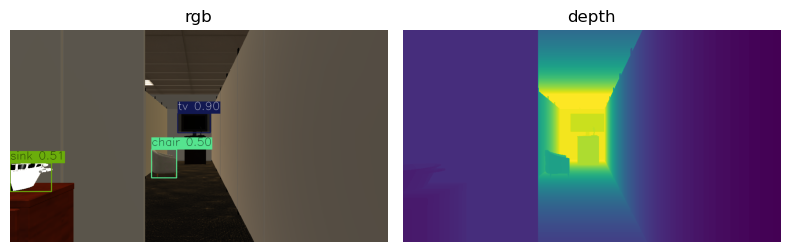

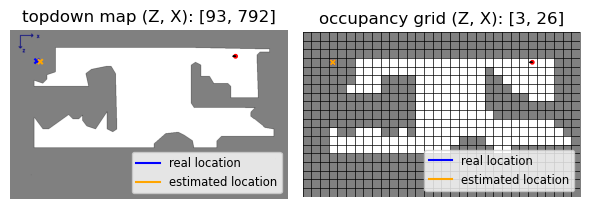


Target object <tv> found after 19 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 19
Travelled distance: 3.12 m
Computed location error: 0.122 m


Simulation 1/100


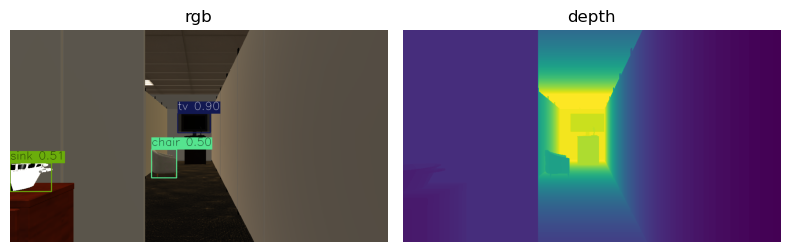

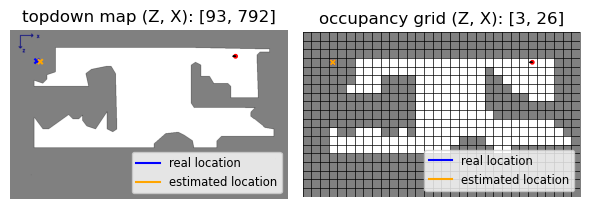


Target object <tv> found after 15 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 15
Travelled distance: 2.50 m
Computed location error: 0.122 m


Simulation 2/100


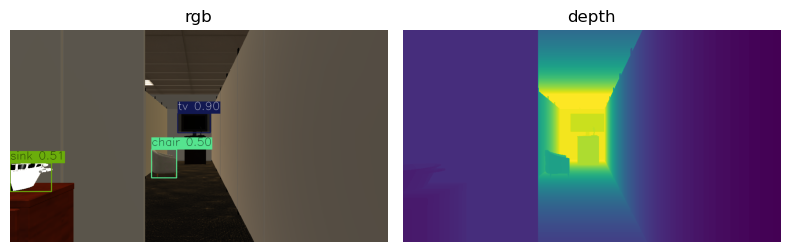

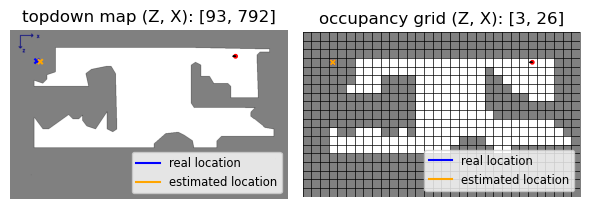


Target object <tv> found after 14 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 14
Travelled distance: 1.87 m
Computed location error: 0.122 m


Simulation 3/100


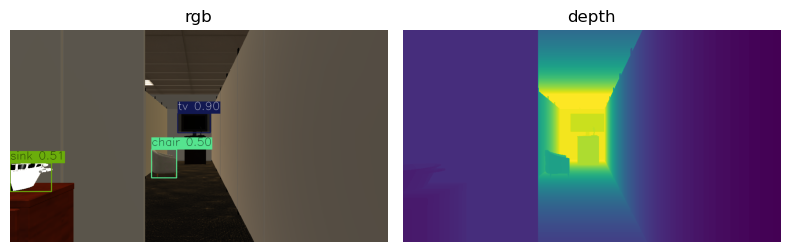

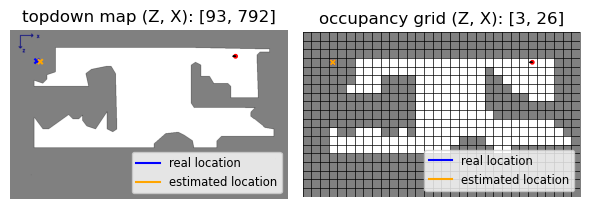


Target object <tv> found after 22 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 22
Travelled distance: 3.41 m
Computed location error: 0.122 m


Simulation 4/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


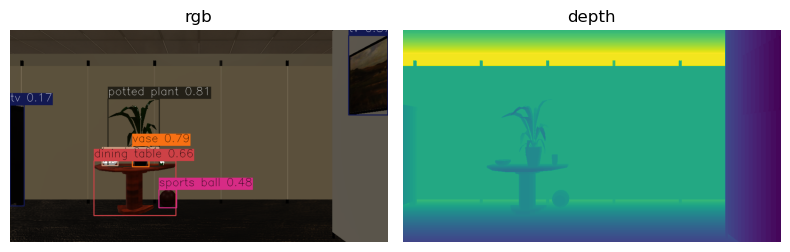

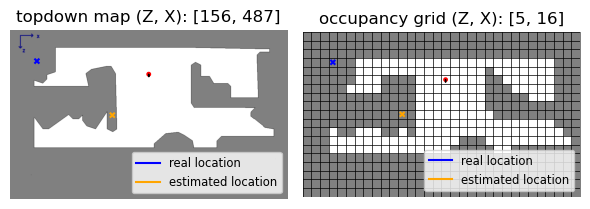


Target object <tv> not found after 21 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 21
Travelled distance: 3.68 m
Computed location error: 3.253 m


Simulation 5/100


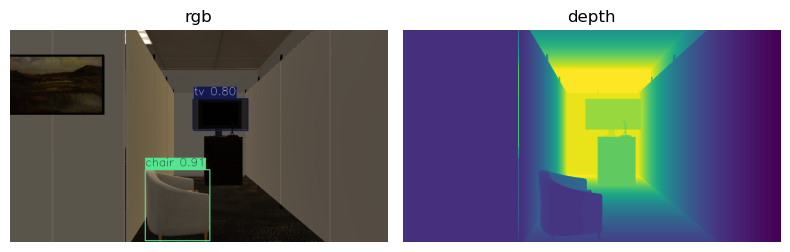

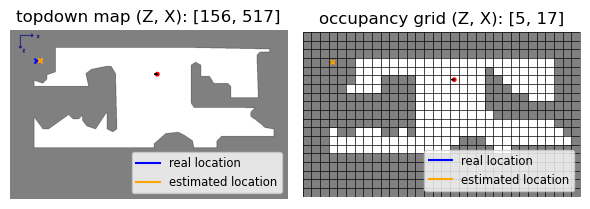


Target object <tv> found after 33 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 33
Travelled distance: 6.46 m
Computed location error: 0.121 m


Simulation 6/100


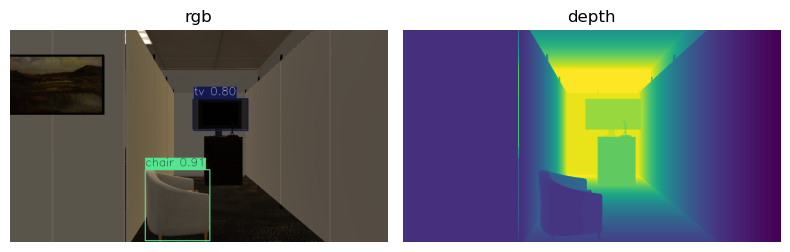

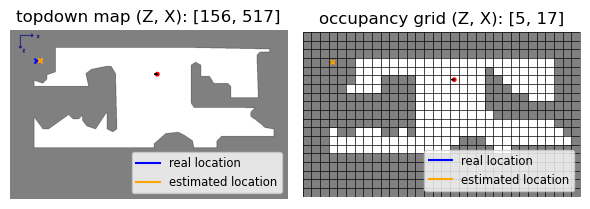


Target object <tv> found after 21 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 21
Travelled distance: 4.01 m
Computed location error: 0.121 m


Simulation 7/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


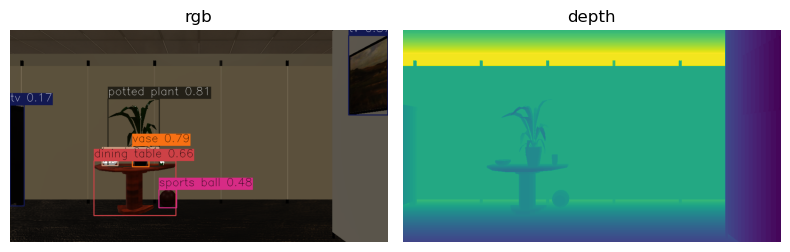

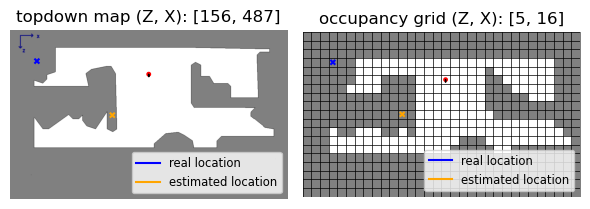


Target object <tv> not found after 6 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 6
Travelled distance: 0.92 m
Computed location error: 3.253 m


Simulation 8/100


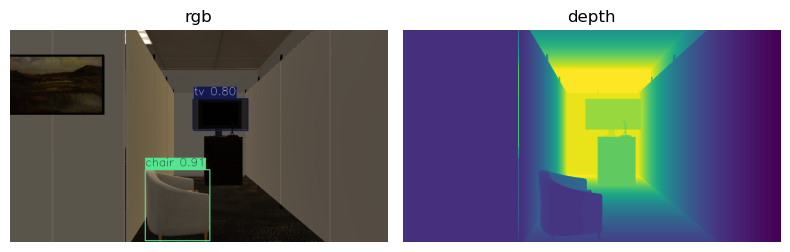

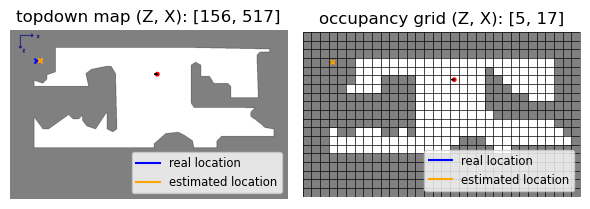


Target object <tv> found after 34 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 34
Travelled distance: 6.16 m
Computed location error: 0.121 m


Simulation 9/100


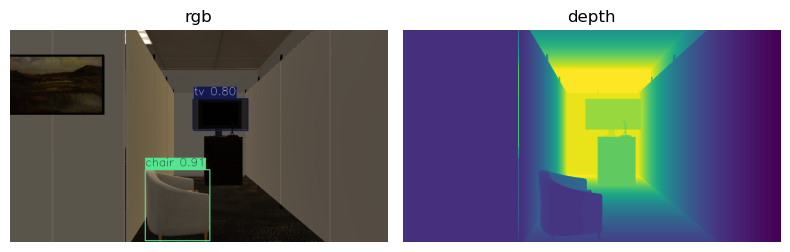

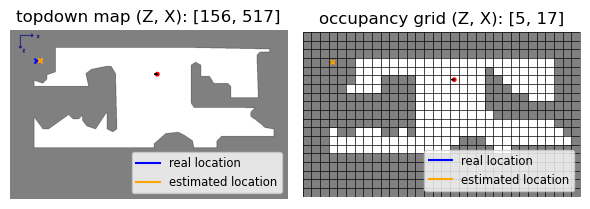


Target object <tv> found after 36 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 36
Travelled distance: 6.78 m
Computed location error: 0.121 m


Simulation 10/100


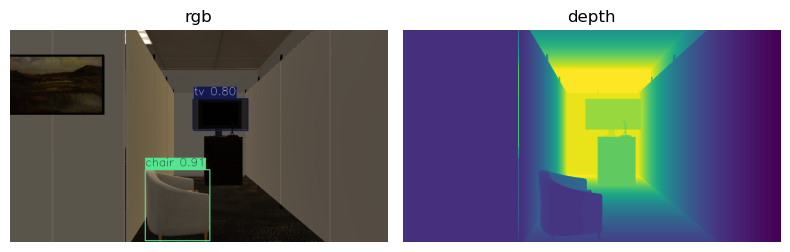

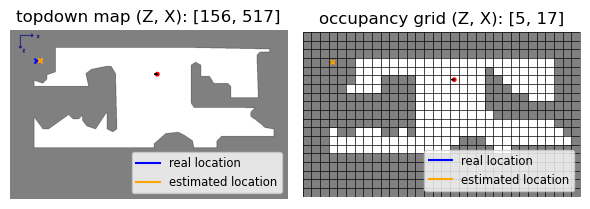


Target object <tv> found after 27 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 27
Travelled distance: 5.54 m
Computed location error: 0.121 m


Simulation 11/100


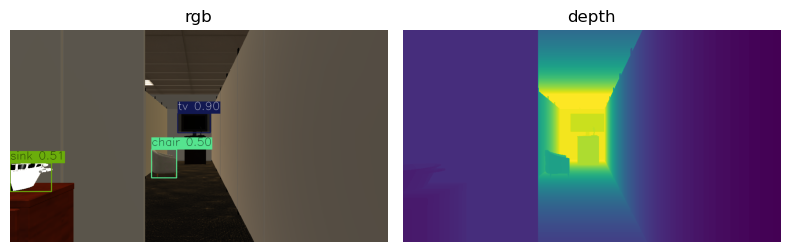

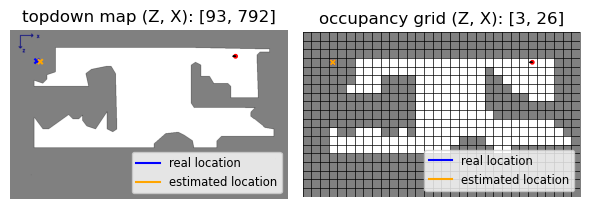


Target object <tv> found after 13 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 13
Travelled distance: 2.51 m
Computed location error: 0.122 m


Simulation 12/100


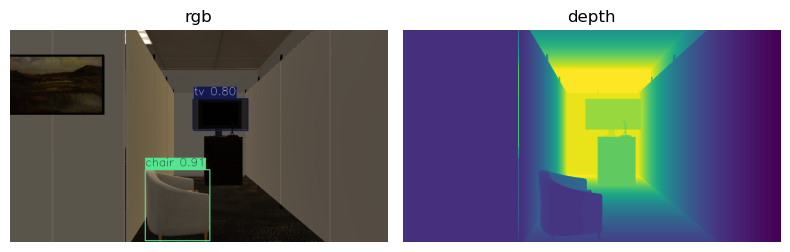

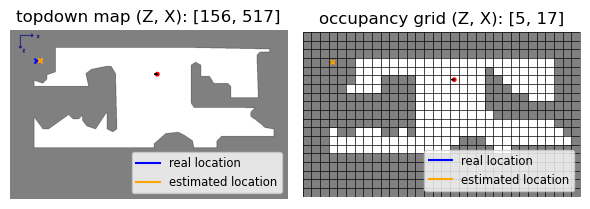


Target object <tv> found after 32 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 32
Travelled distance: 5.55 m
Computed location error: 0.121 m


Simulation 13/100


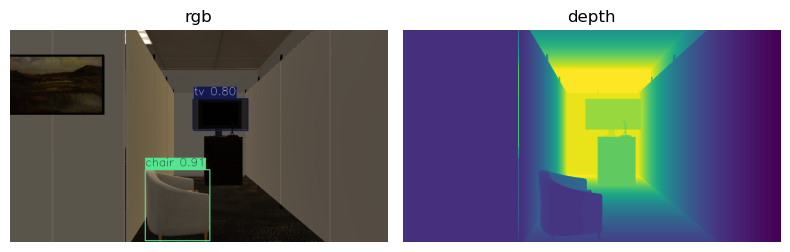

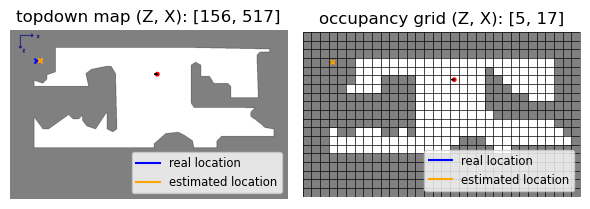


Target object <tv> found after 19 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 19
Travelled distance: 3.40 m
Computed location error: 0.121 m


Simulation 14/100


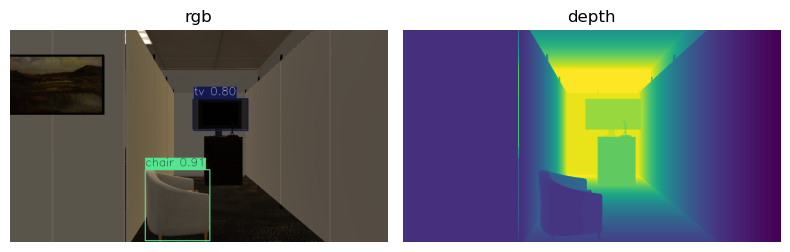

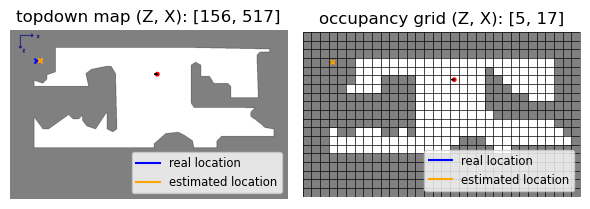


Target object <tv> found after 28 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 28
Travelled distance: 5.24 m
Computed location error: 0.121 m


Simulation 15/100


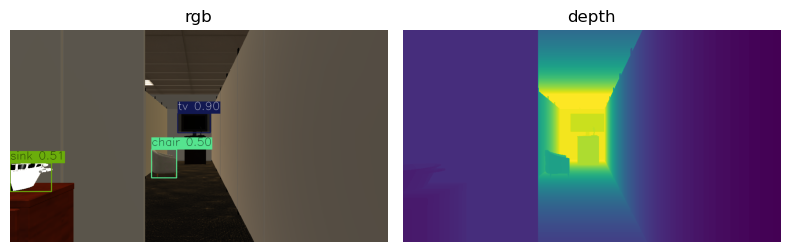

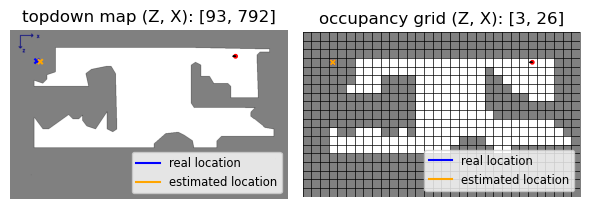


Target object <tv> found after 14 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 14
Travelled distance: 1.87 m
Computed location error: 0.122 m


Simulation 16/100


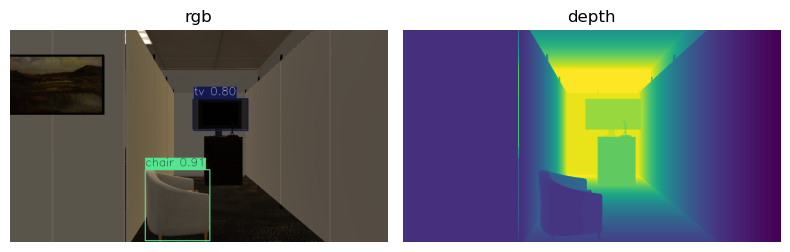

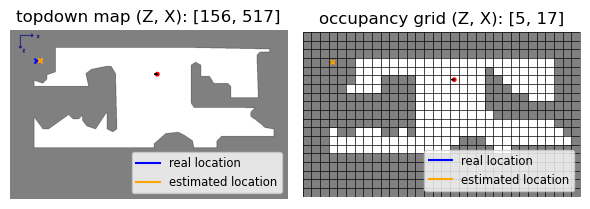


Target object <tv> found after 34 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 34
Travelled distance: 6.16 m
Computed location error: 0.121 m


Simulation 17/100


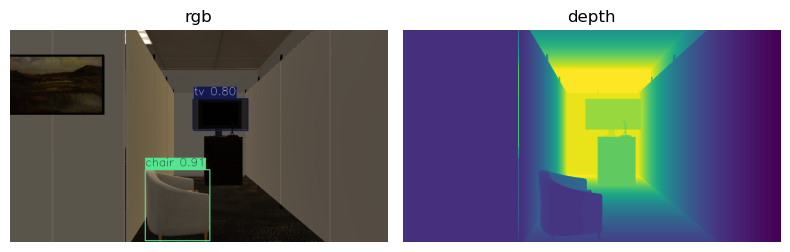

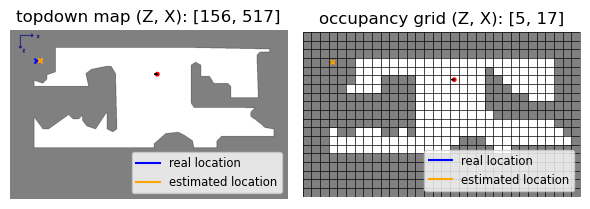


Target object <tv> found after 8 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 8
Travelled distance: 0.94 m
Computed location error: 0.121 m


Simulation 18/100


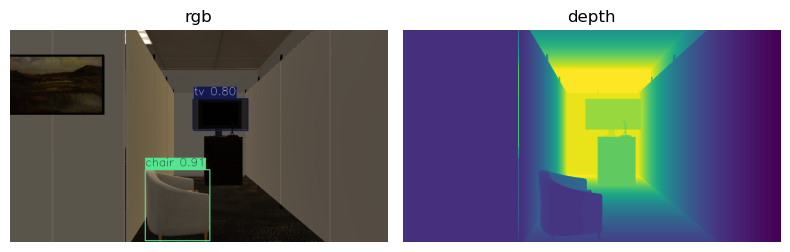

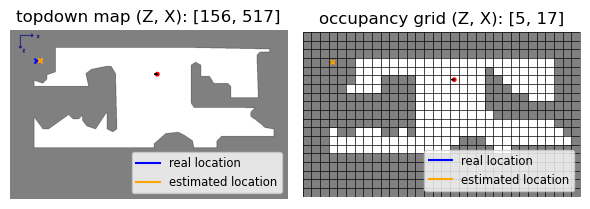


Target object <tv> found after 19 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 19
Travelled distance: 3.40 m
Computed location error: 0.121 m


Simulation 19/100


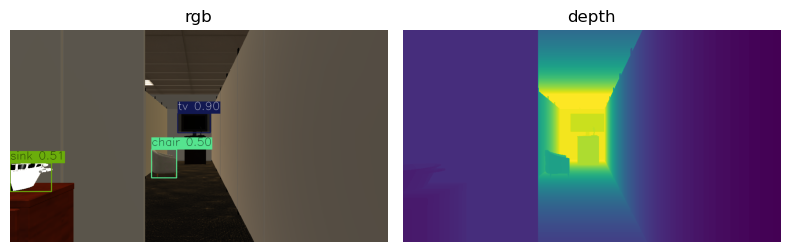

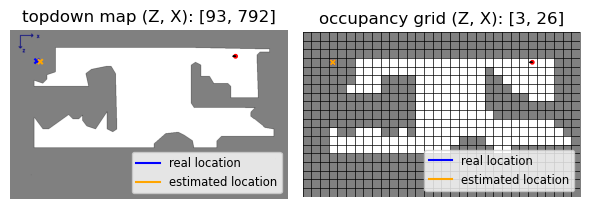


Target object <tv> found after 8 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 8
Travelled distance: 1.25 m
Computed location error: 0.122 m


Simulation 20/100


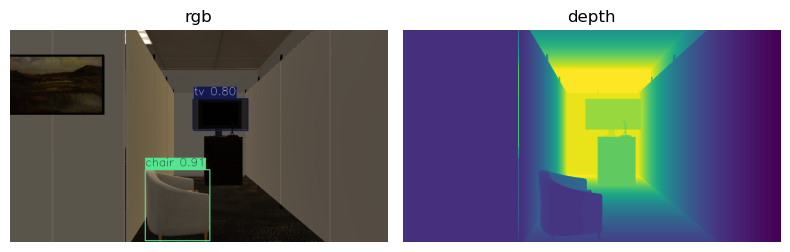

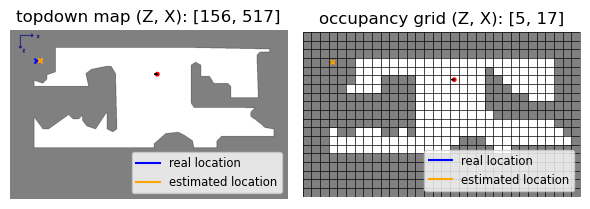


Target object <tv> found after 25 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 25
Travelled distance: 5.23 m
Computed location error: 0.121 m


Simulation 21/100


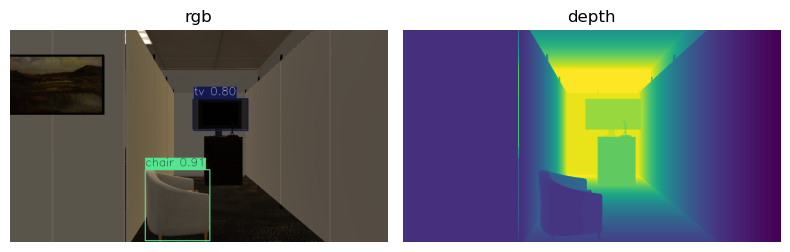

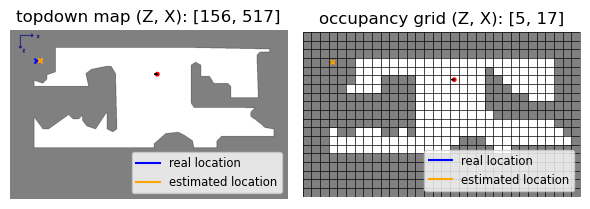


Target object <tv> found after 36 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 36
Travelled distance: 6.78 m
Computed location error: 0.121 m


Simulation 22/100


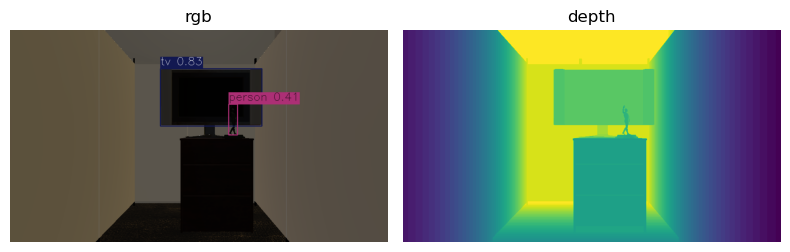

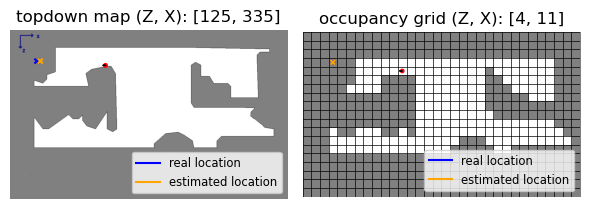


Target object <tv> found after 1 actions!
Found location: [    -9.3766     -0.4641      -4.242]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 1
Travelled distance: 0.30 m
Computed location error: 0.120 m


Simulation 23/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


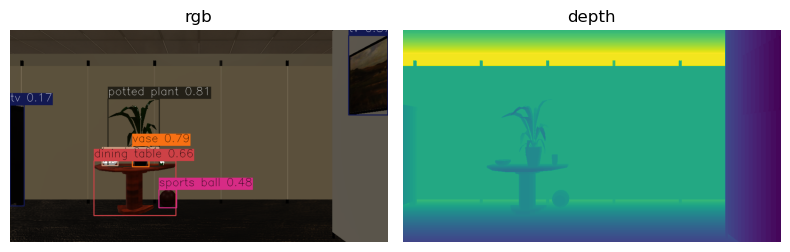

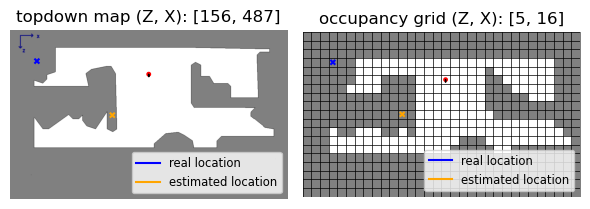


Target object <tv> not found after 5 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 5
Travelled distance: 0.92 m
Computed location error: 3.253 m


Simulation 24/100


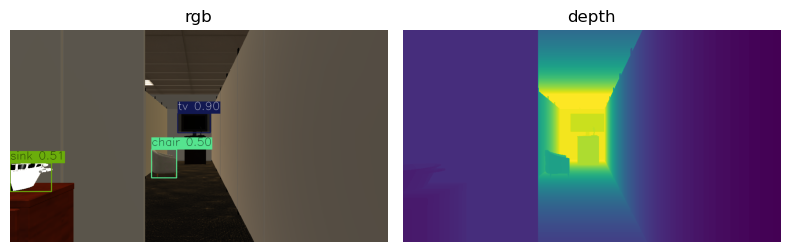

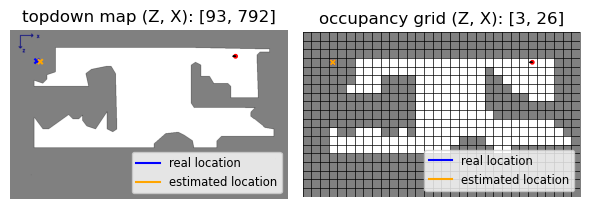


Target object <tv> found after 12 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 12
Travelled distance: 1.86 m
Computed location error: 0.122 m


Simulation 25/100


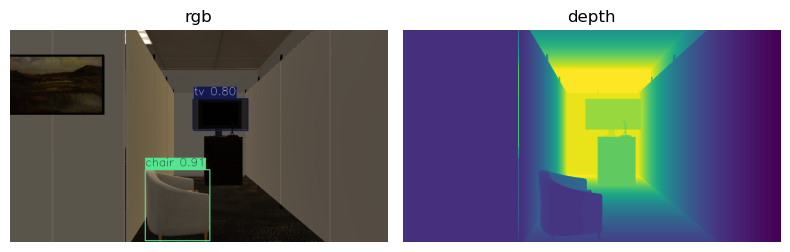

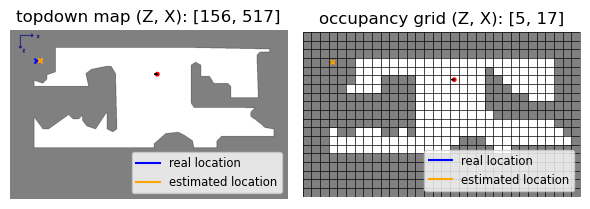


Target object <tv> found after 7 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 7
Travelled distance: 0.62 m
Computed location error: 0.121 m


Simulation 26/100


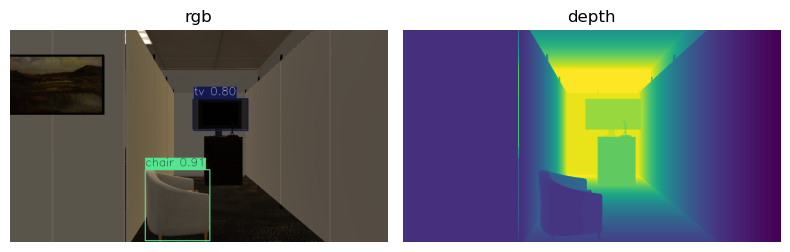

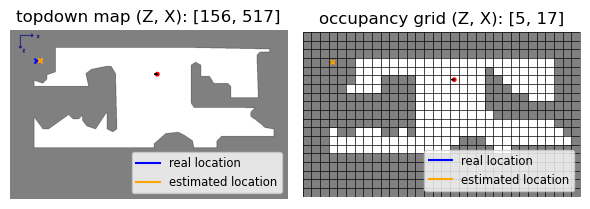


Target object <tv> found after 22 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 22
Travelled distance: 3.73 m
Computed location error: 0.121 m


Simulation 27/100


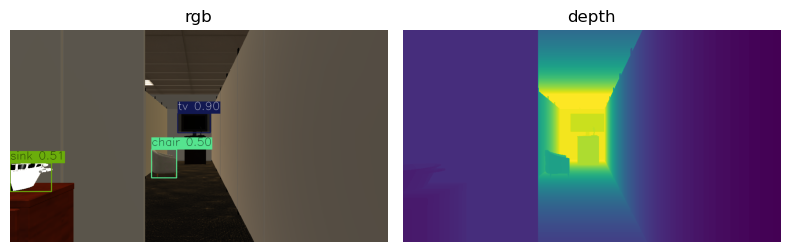

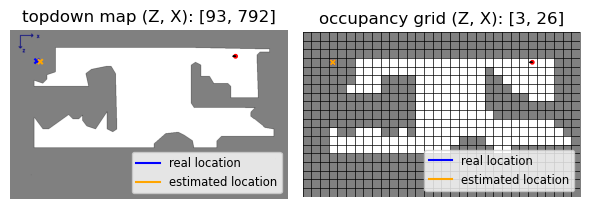


Target object <tv> found after 17 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 2.81 m
Computed location error: 0.122 m


Simulation 28/100


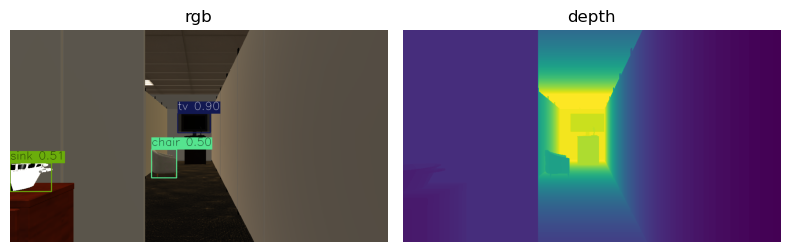

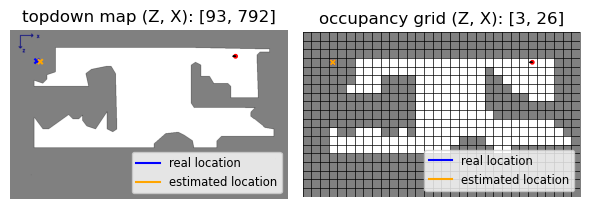


Target object <tv> found after 13 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 13
Travelled distance: 2.19 m
Computed location error: 0.122 m


Simulation 29/100


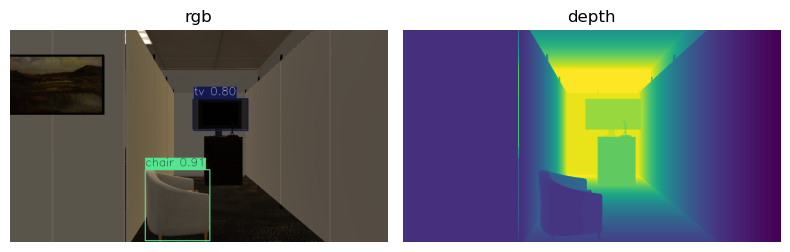

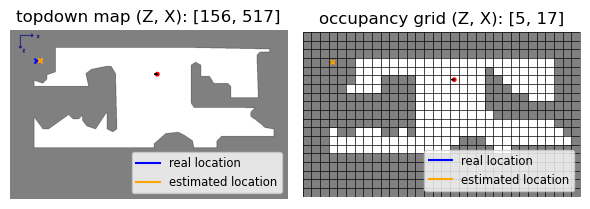


Target object <tv> found after 13 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 13
Travelled distance: 1.85 m
Computed location error: 0.121 m


Simulation 30/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


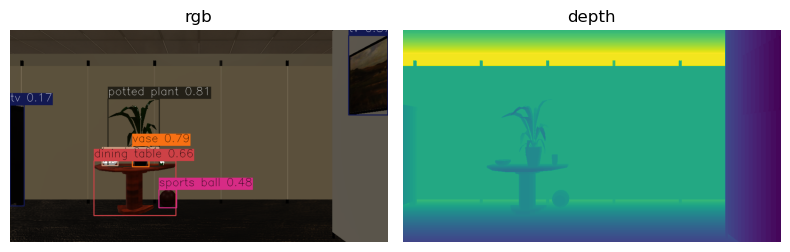

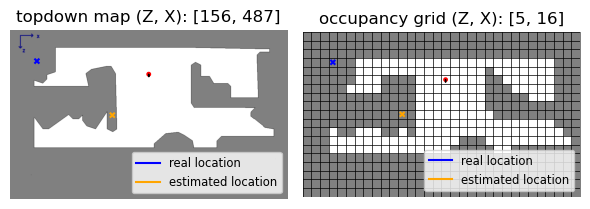


Target object <tv> not found after 14 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 14
Travelled distance: 2.75 m
Computed location error: 3.253 m


Simulation 31/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


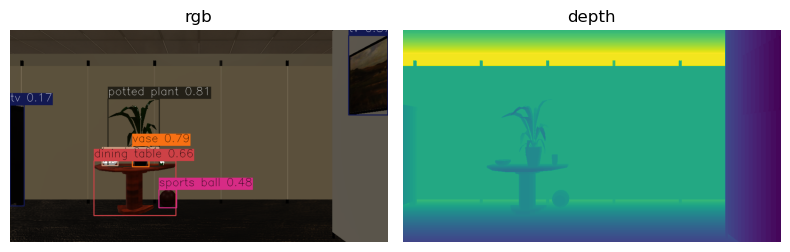

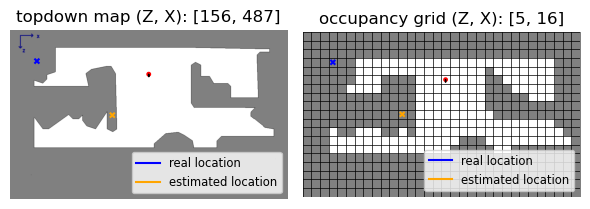


Target object <tv> not found after 16 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 3.07 m
Computed location error: 3.253 m


Simulation 32/100


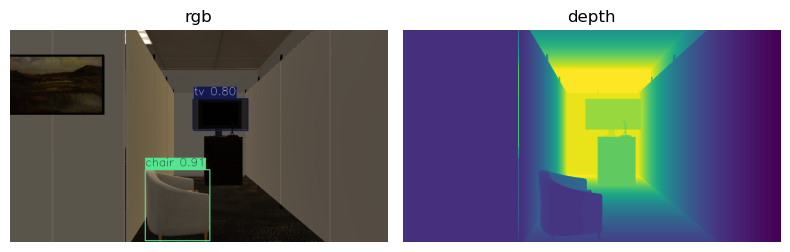

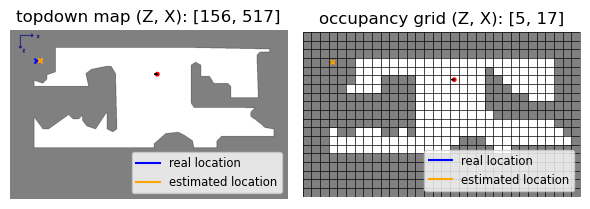


Target object <tv> found after 11 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 11
Travelled distance: 1.54 m
Computed location error: 0.121 m


Simulation 33/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


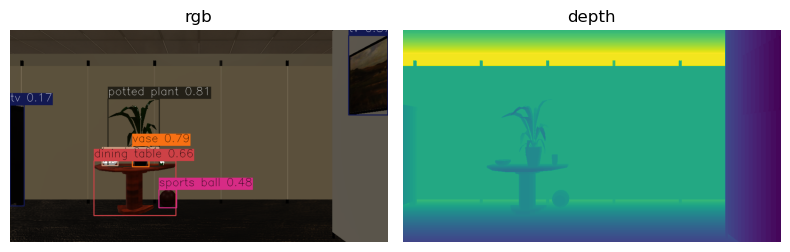

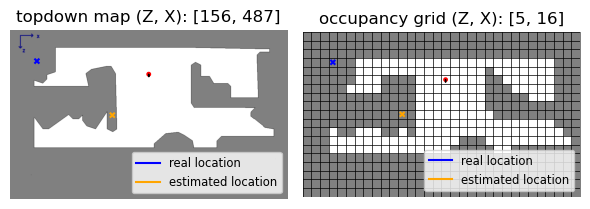


Target object <tv> not found after 24 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 24
Travelled distance: 4.29 m
Computed location error: 3.253 m


Simulation 34/100


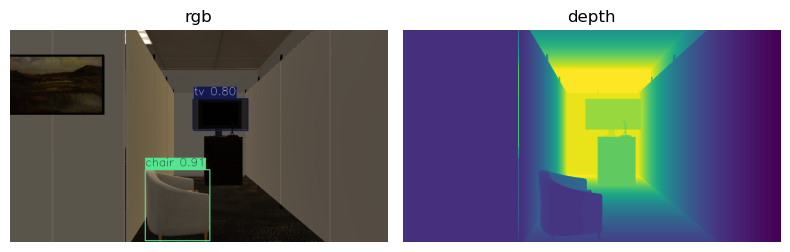

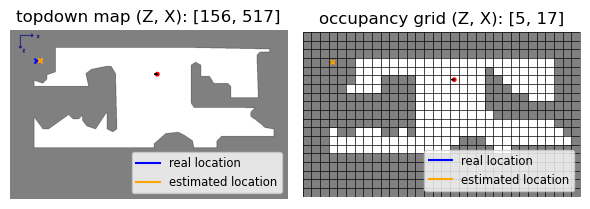


Target object <tv> found after 17 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 2.80 m
Computed location error: 0.121 m


Simulation 35/100


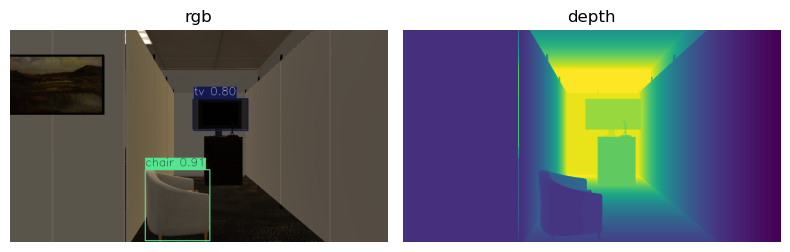

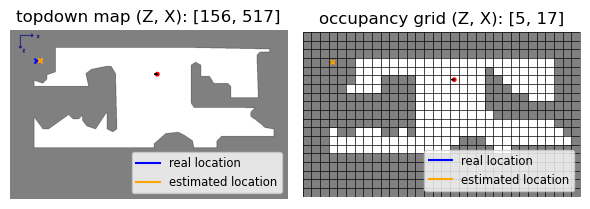


Target object <tv> found after 16 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 2.49 m
Computed location error: 0.121 m


Simulation 36/100


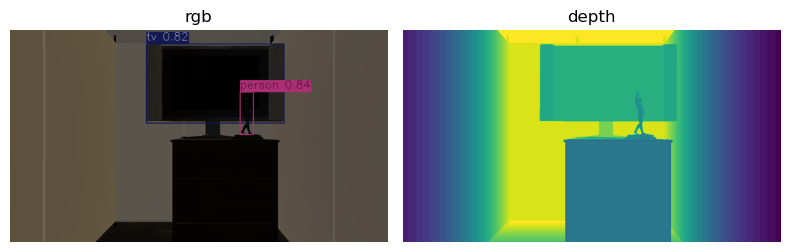

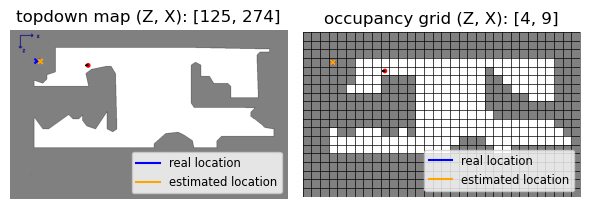


Target object <tv> found after 2 actions!
Found location: [    -9.3766    -0.46122     -4.2399]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 2
Travelled distance: 0.00 m
Computed location error: 0.120 m


Simulation 37/100


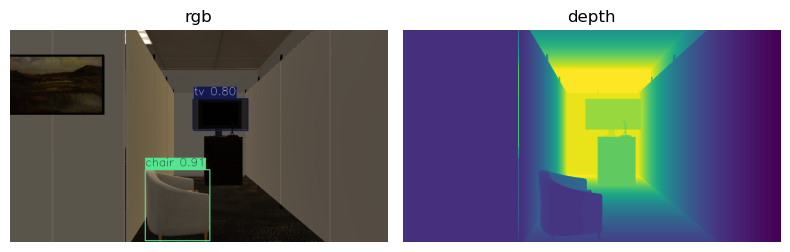

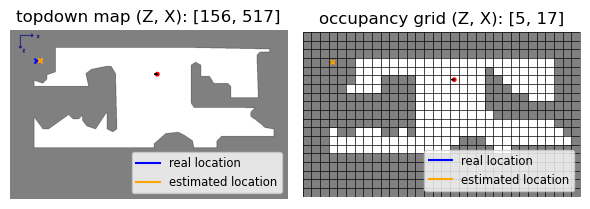


Target object <tv> found after 26 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 26
Travelled distance: 4.34 m
Computed location error: 0.121 m


Simulation 38/100


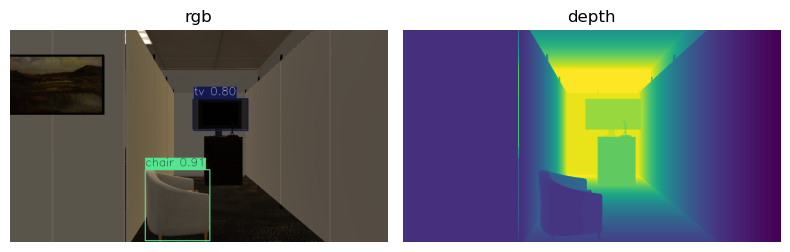

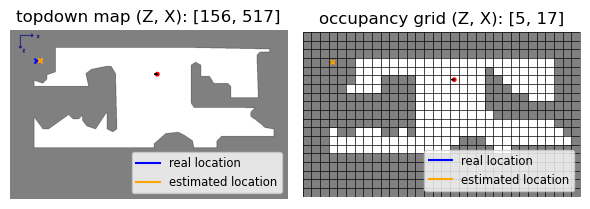


Target object <tv> found after 22 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 22
Travelled distance: 3.71 m
Computed location error: 0.121 m


Simulation 39/100


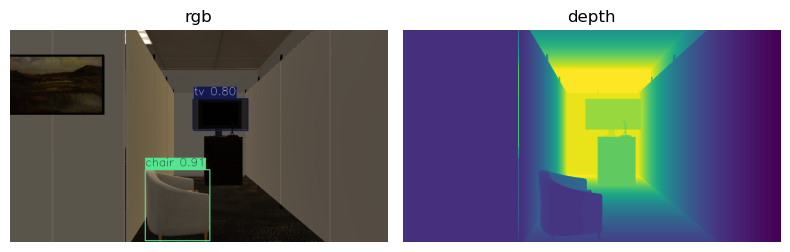

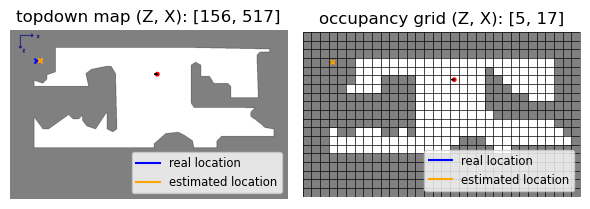


Target object <tv> found after 23 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 23
Travelled distance: 4.01 m
Computed location error: 0.121 m


Simulation 40/100


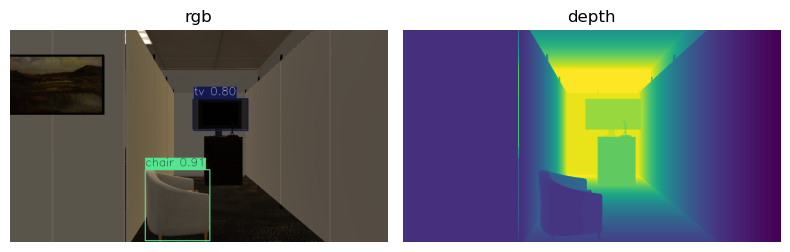

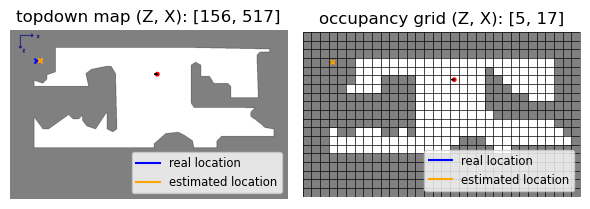


Target object <tv> found after 4 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 4
Travelled distance: 0.63 m
Computed location error: 0.121 m


Simulation 41/100


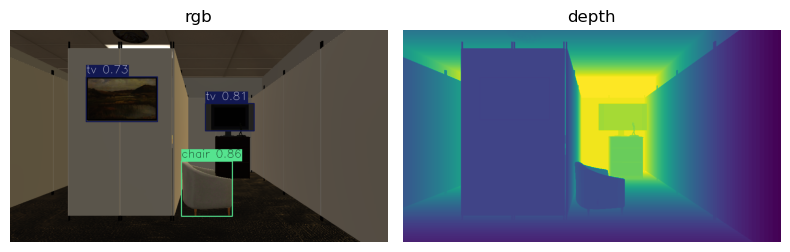

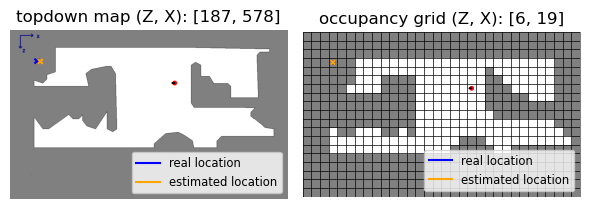


Target object <tv> found after 1 actions!
Found location: [    -9.3765     -0.4614     -4.2388]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.120 m


Simulation 42/100


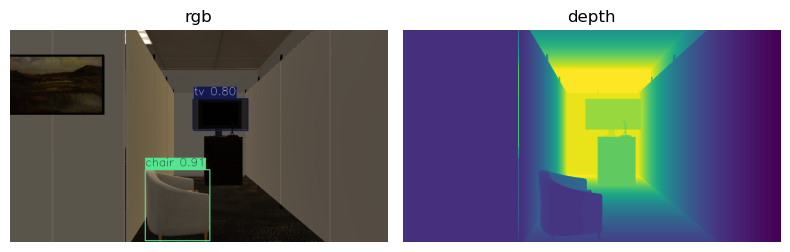

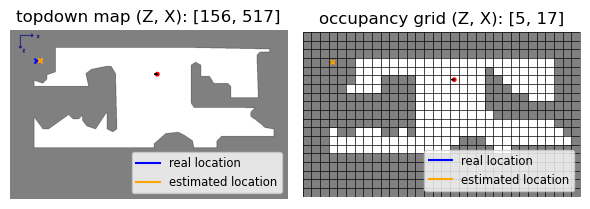


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 3.12 m
Computed location error: 0.121 m


Simulation 43/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


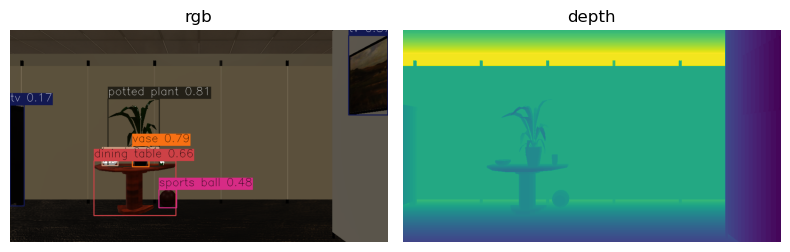

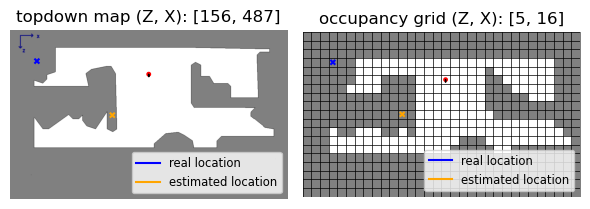


Target object <tv> not found after 17 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 3.37 m
Computed location error: 3.253 m


Simulation 44/100


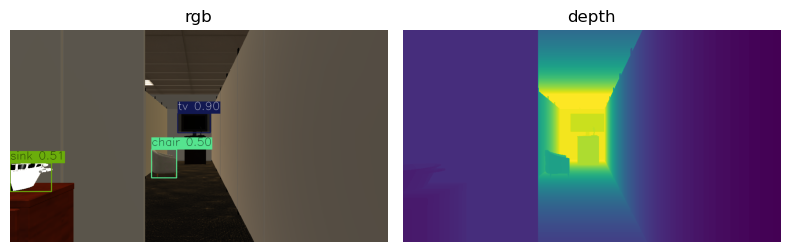

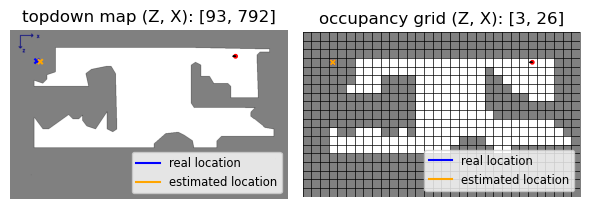


Target object <tv> found after 17 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 2.81 m
Computed location error: 0.122 m


Simulation 45/100


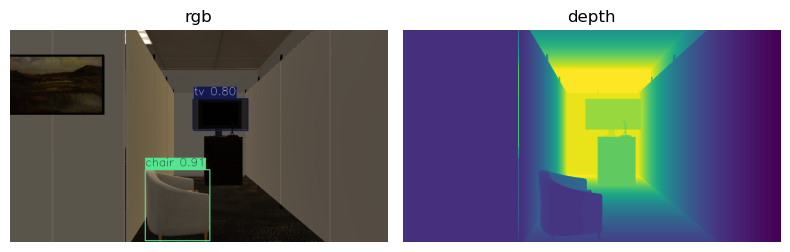

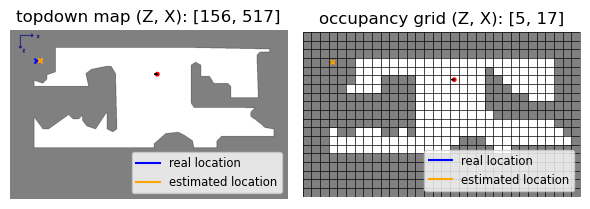


Target object <tv> found after 10 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 10
Travelled distance: 1.53 m
Computed location error: 0.121 m


Simulation 46/100


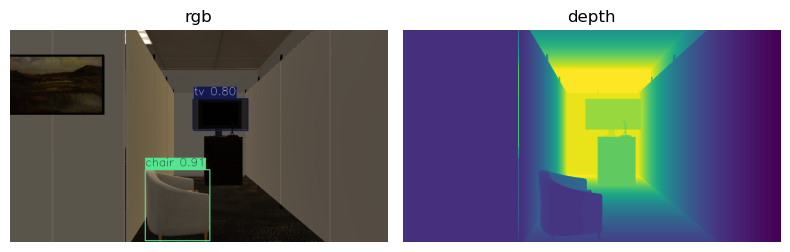

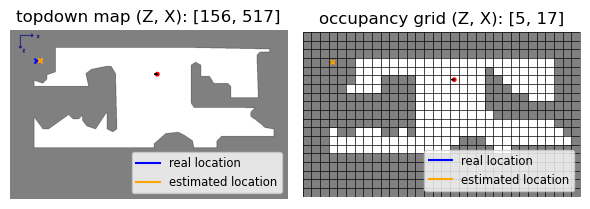


Target object <tv> found after 18 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 18
Travelled distance: 2.79 m
Computed location error: 0.121 m


Simulation 47/100


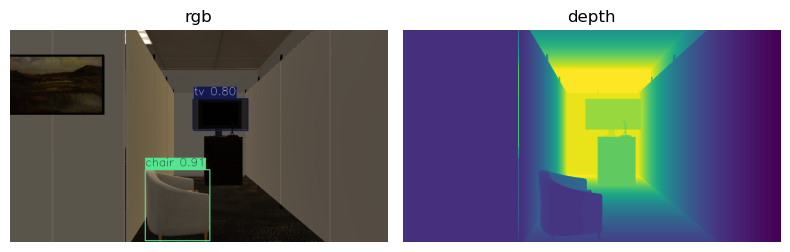

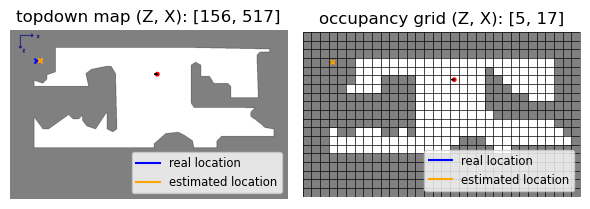


Target object <tv> found after 9 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 9
Travelled distance: 1.23 m
Computed location error: 0.121 m


Simulation 48/100


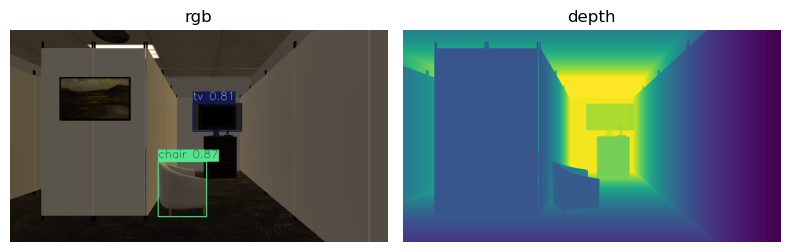

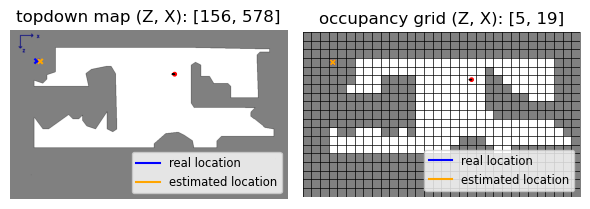


Target object <tv> found after 2 actions!
Found location: [    -9.3765     -0.4614     -4.2382]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 2
Travelled distance: 0.30 m
Computed location error: 0.120 m


Simulation 49/100


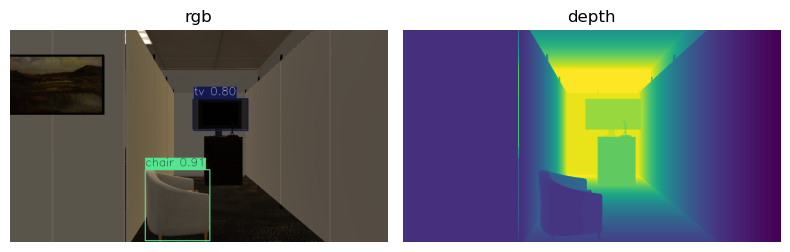

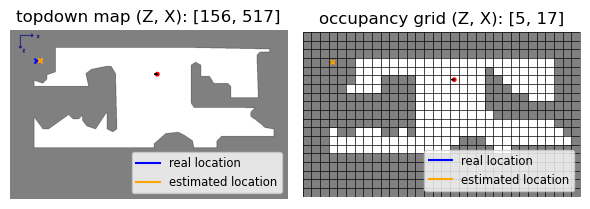


Target object <tv> found after 36 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 36
Travelled distance: 6.47 m
Computed location error: 0.121 m


Simulation 50/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


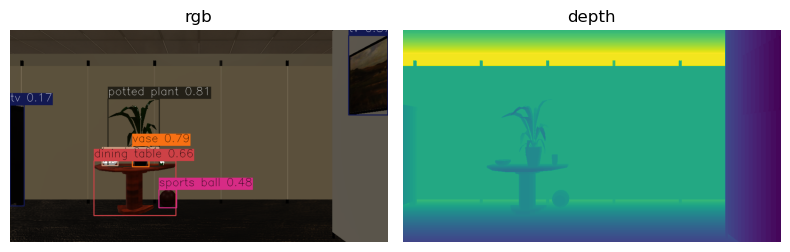

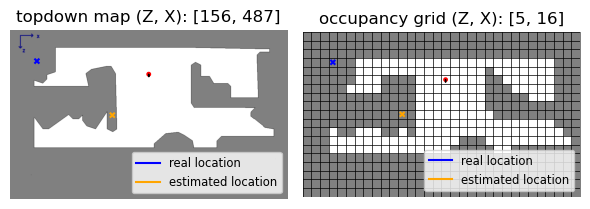


Target object <tv> not found after 24 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 24
Travelled distance: 4.29 m
Computed location error: 3.253 m


Simulation 51/100


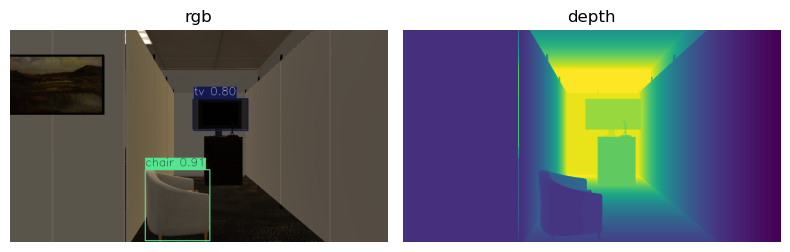

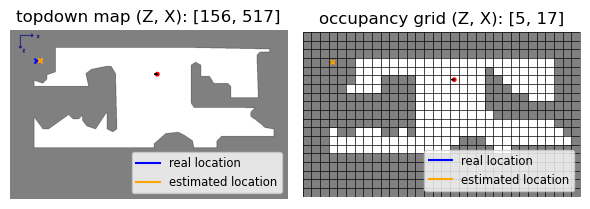


Target object <tv> found after 19 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 19
Travelled distance: 3.41 m
Computed location error: 0.121 m


Simulation 52/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


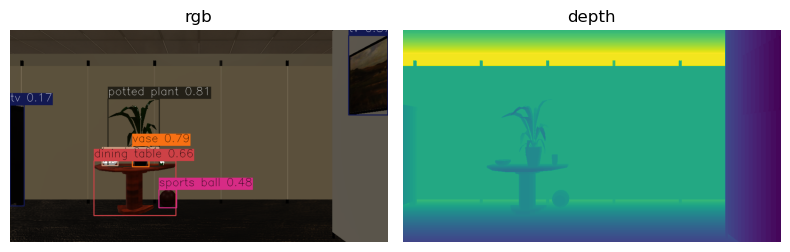

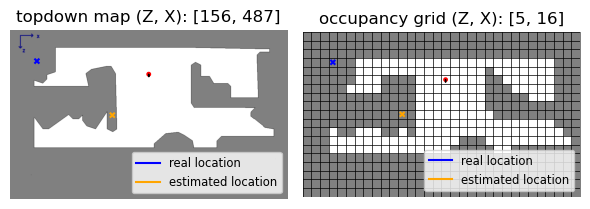


Target object <tv> not found after 20 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 3.68 m
Computed location error: 3.253 m


Simulation 53/100


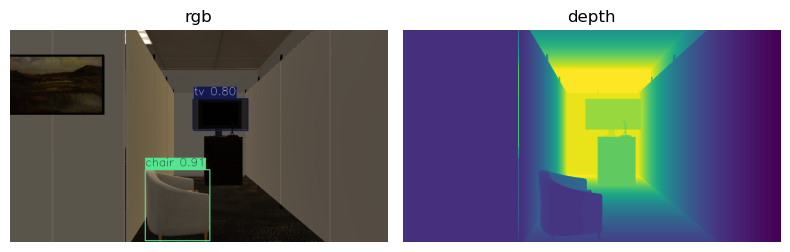

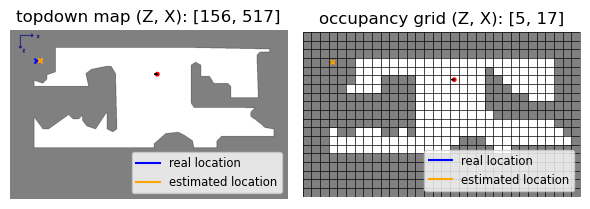


Target object <tv> found after 34 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 34
Travelled distance: 6.46 m
Computed location error: 0.121 m


Simulation 54/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


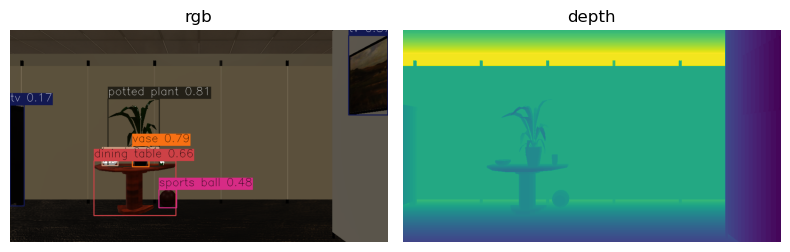

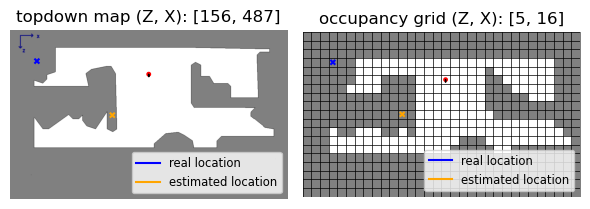


Target object <tv> not found after 21 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 21
Travelled distance: 3.68 m
Computed location error: 3.253 m


Simulation 55/100


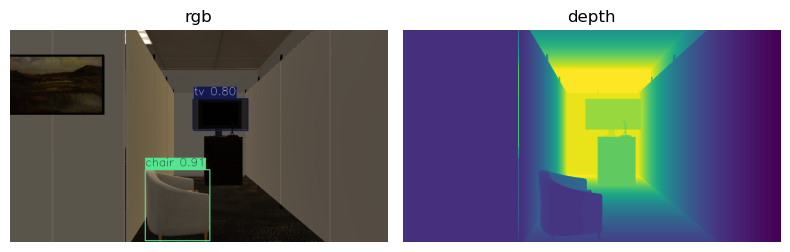

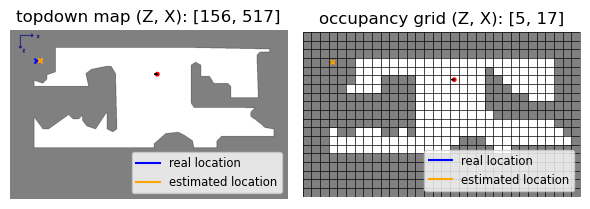


Target object <tv> found after 9 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 9
Travelled distance: 1.54 m
Computed location error: 0.121 m


Simulation 56/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


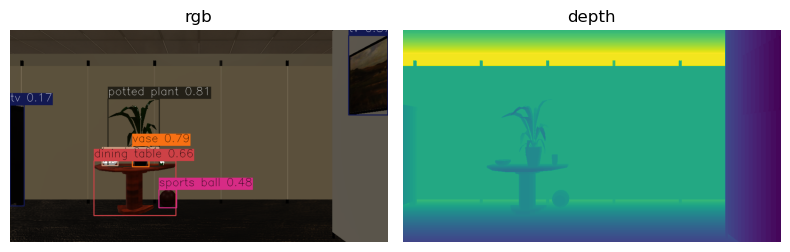

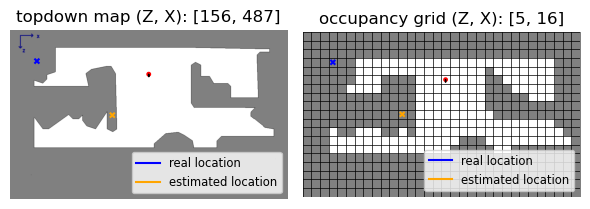


Target object <tv> not found after 22 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 22
Travelled distance: 3.68 m
Computed location error: 3.253 m


Simulation 57/100


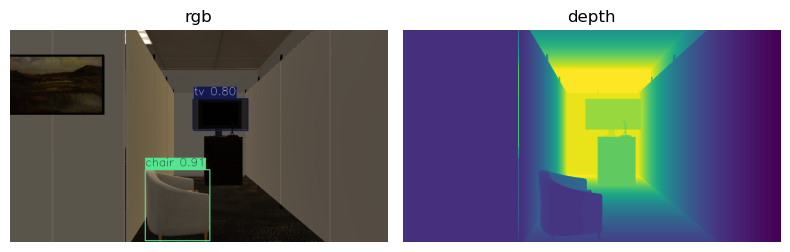

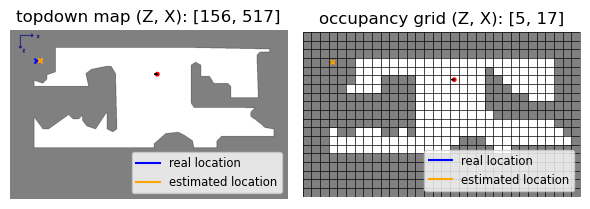


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 2.81 m
Computed location error: 0.121 m


Simulation 58/100


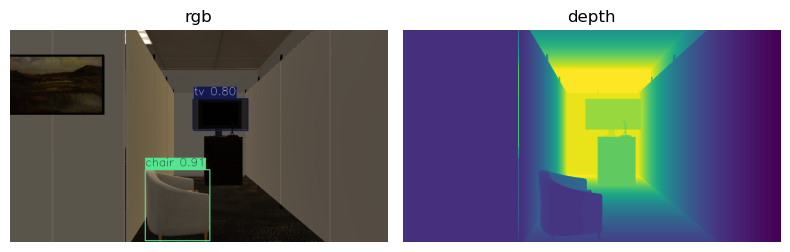

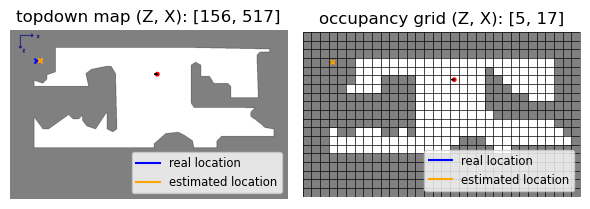


Target object <tv> found after 30 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 30
Travelled distance: 5.56 m
Computed location error: 0.121 m


Simulation 59/100


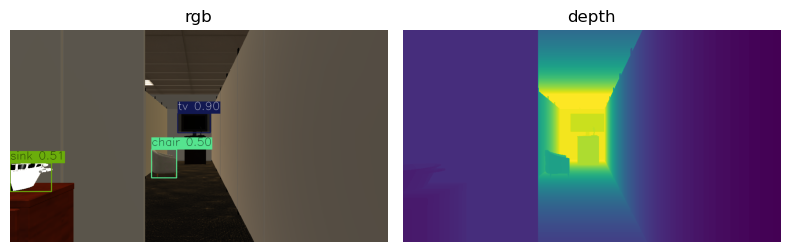

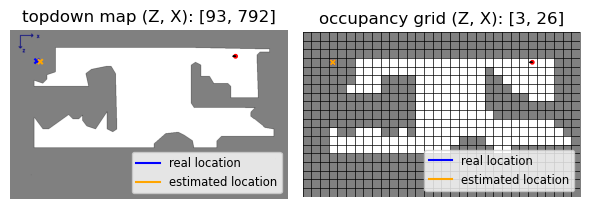


Target object <tv> found after 18 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 18
Travelled distance: 2.80 m
Computed location error: 0.122 m


Simulation 60/100


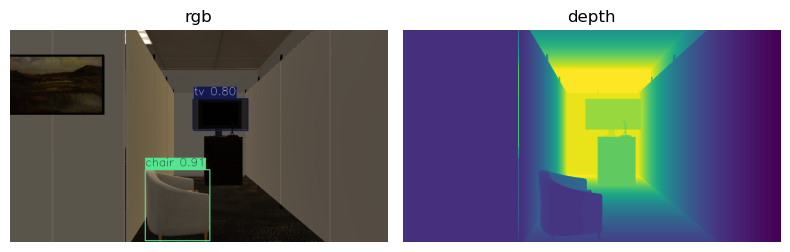

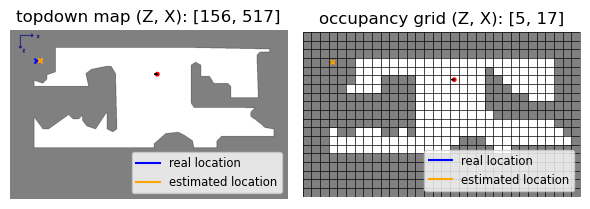


Target object <tv> found after 24 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 24
Travelled distance: 4.33 m
Computed location error: 0.121 m


Simulation 61/100


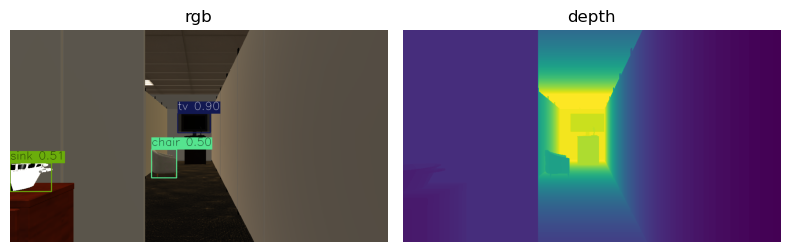

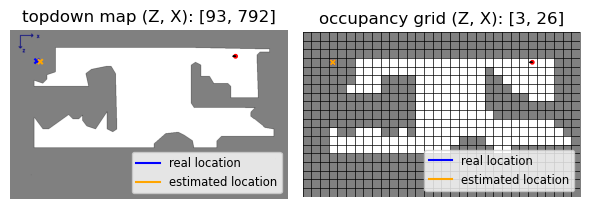


Target object <tv> found after 15 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 15
Travelled distance: 2.18 m
Computed location error: 0.122 m


Simulation 62/100


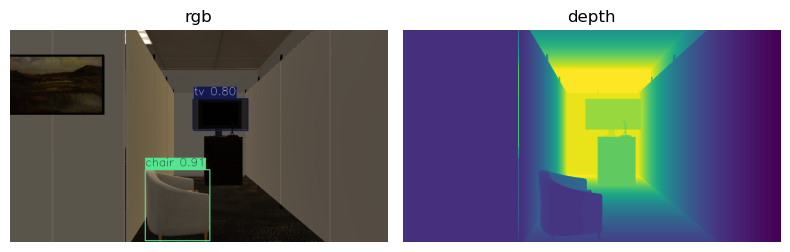

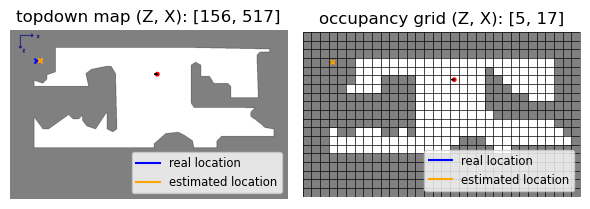


Target object <tv> found after 1 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.121 m


Simulation 63/100


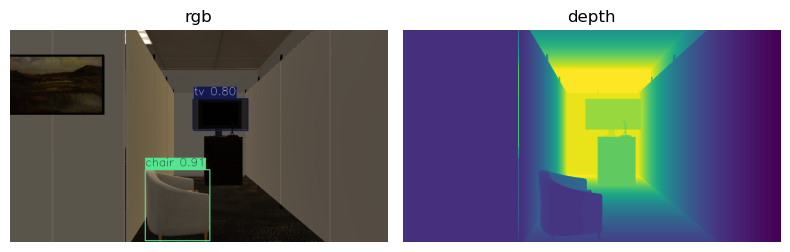

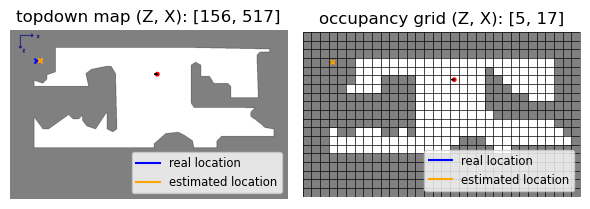


Target object <tv> found after 25 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 25
Travelled distance: 4.62 m
Computed location error: 0.121 m


Simulation 64/100


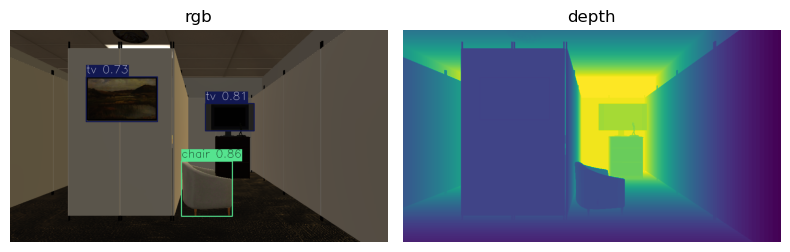

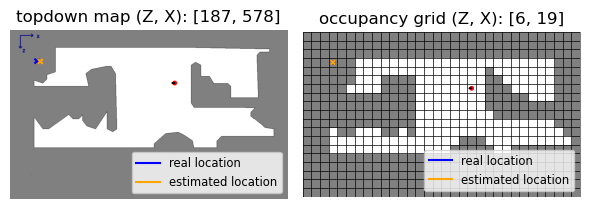


Target object <tv> found after 3 actions!
Found location: [    -9.3765     -0.4614     -4.2388]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 3
Travelled distance: 0.63 m
Computed location error: 0.120 m


Simulation 65/100


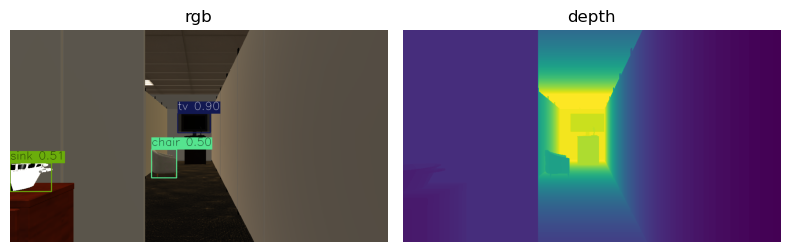

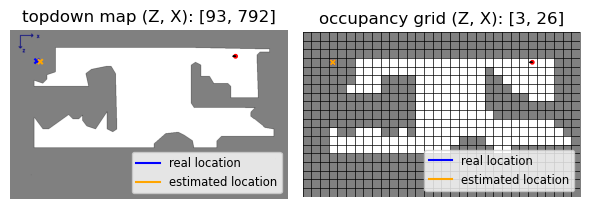


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 3.12 m
Computed location error: 0.122 m


Simulation 66/100


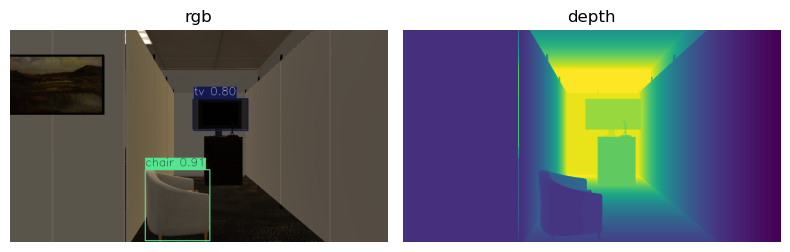

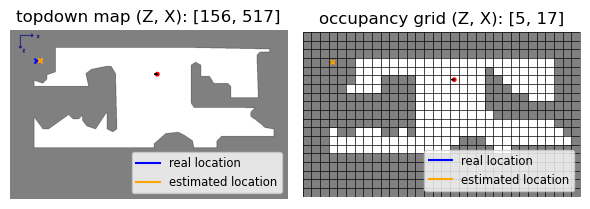


Target object <tv> found after 18 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 18
Travelled distance: 2.49 m
Computed location error: 0.121 m


Simulation 67/100


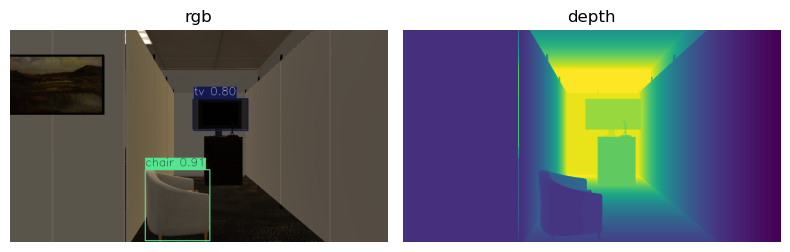

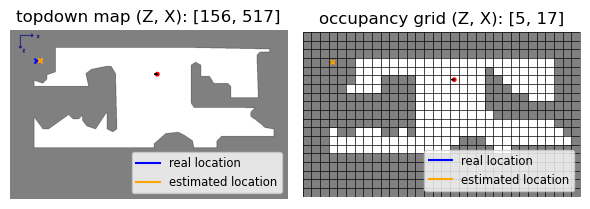


Target object <tv> found after 5 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 5
Travelled distance: 0.63 m
Computed location error: 0.121 m


Simulation 68/100


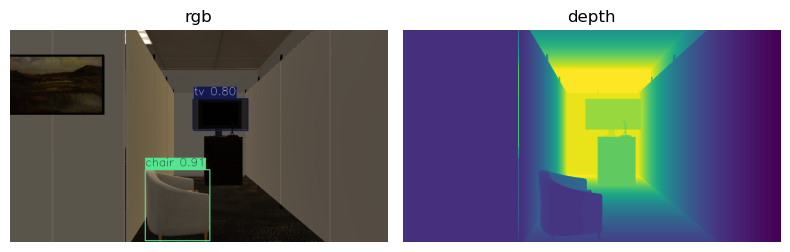

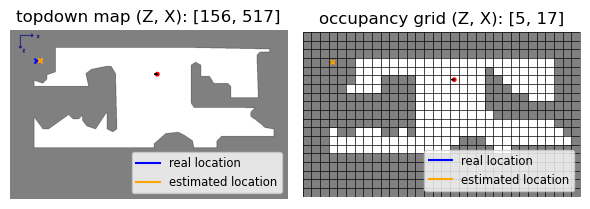


Target object <tv> found after 29 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 29
Travelled distance: 5.24 m
Computed location error: 0.121 m


Simulation 69/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


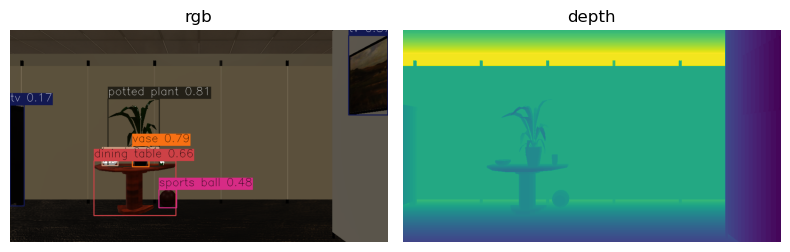

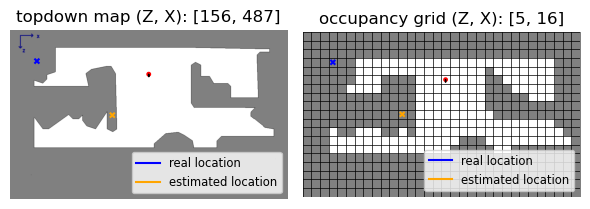


Target object <tv> not found after 16 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 3.07 m
Computed location error: 3.253 m


Simulation 70/100


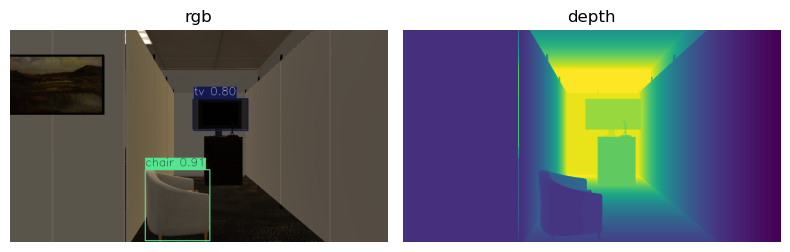

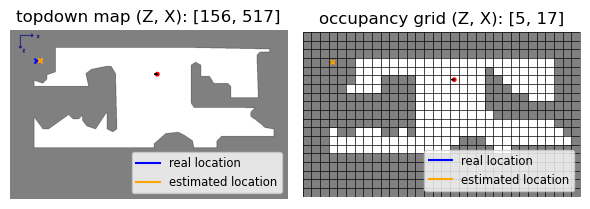


Target object <tv> found after 26 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 26
Travelled distance: 4.94 m
Computed location error: 0.121 m


Simulation 71/100


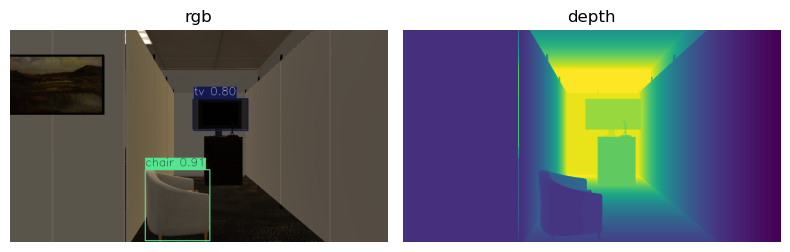

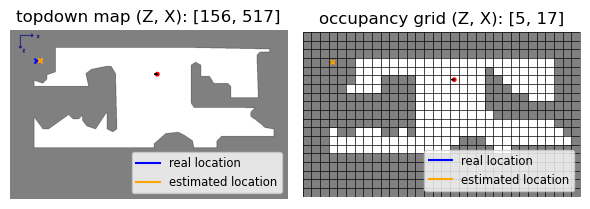


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 3.42 m
Computed location error: 0.121 m


Simulation 72/100


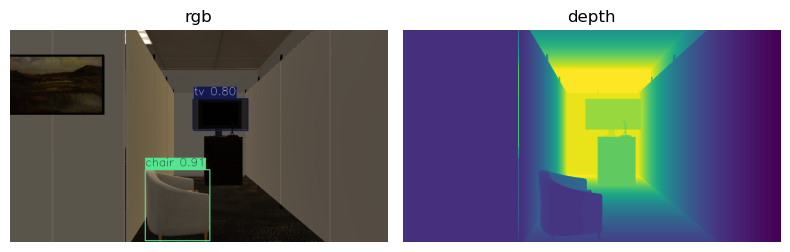

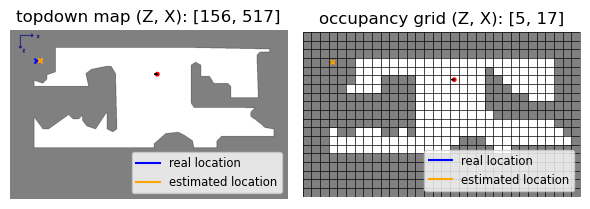


Target object <tv> found after 30 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 30
Travelled distance: 5.55 m
Computed location error: 0.121 m


Simulation 73/100


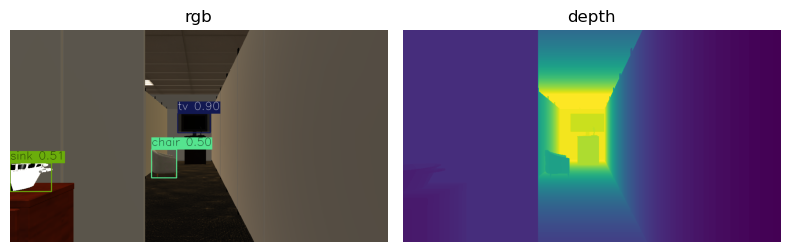

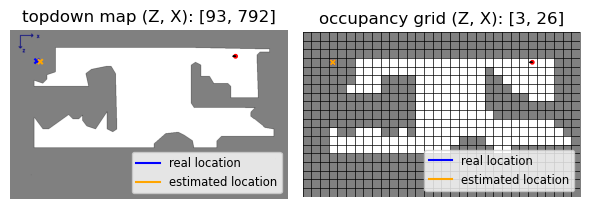


Target object <tv> found after 1 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.122 m


Simulation 74/100


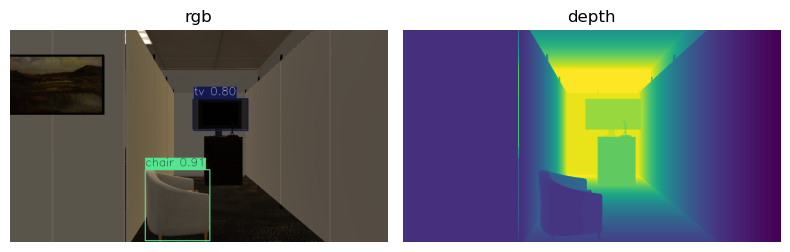

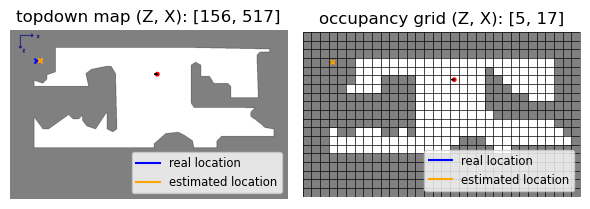


Target object <tv> found after 19 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 19
Travelled distance: 2.81 m
Computed location error: 0.121 m


Simulation 75/100


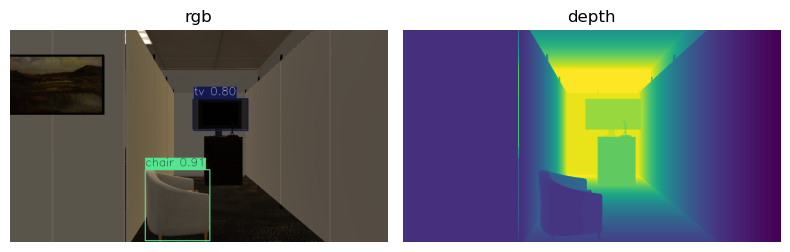

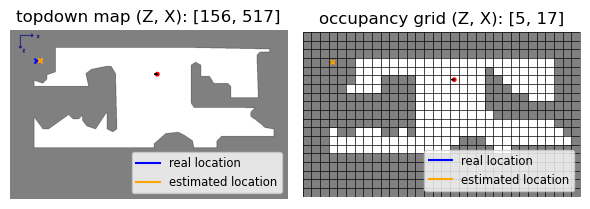


Target object <tv> found after 26 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 26
Travelled distance: 4.33 m
Computed location error: 0.121 m


Simulation 76/100


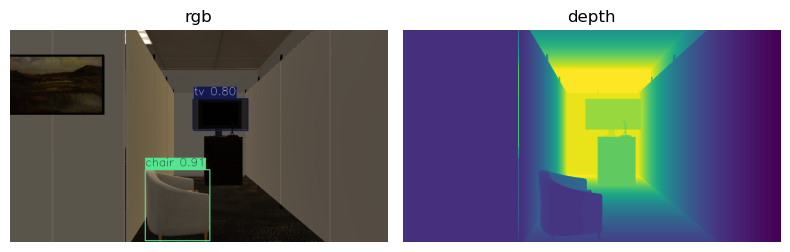

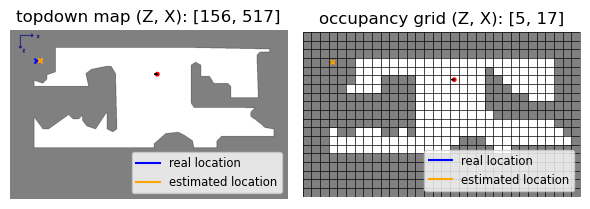


Target object <tv> found after 21 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 21
Travelled distance: 3.41 m
Computed location error: 0.121 m


Simulation 77/100


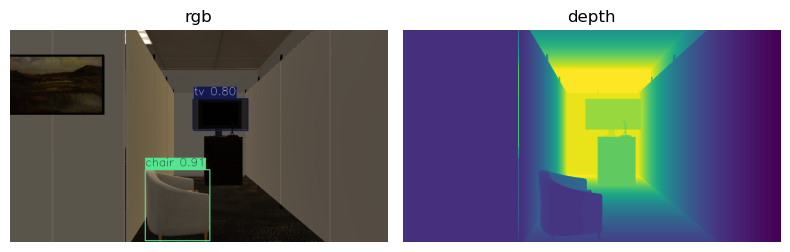

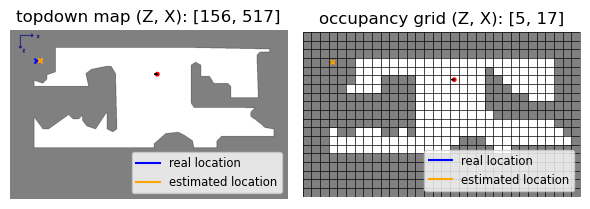


Target object <tv> found after 8 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 8
Travelled distance: 0.93 m
Computed location error: 0.121 m


Simulation 78/100


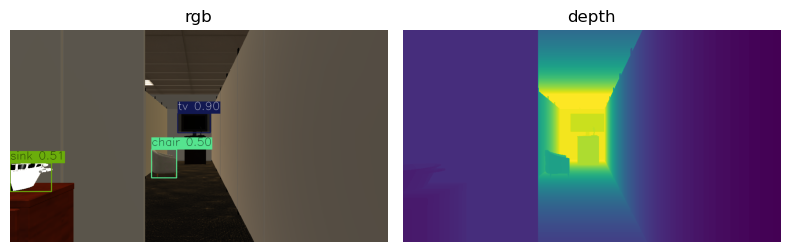

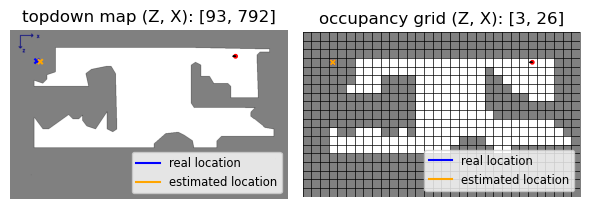


Target object <tv> found after 14 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 14
Travelled distance: 2.18 m
Computed location error: 0.122 m


Simulation 79/100

Location error 3.074 m exceeds threshold 0.5 m. FAILURE!


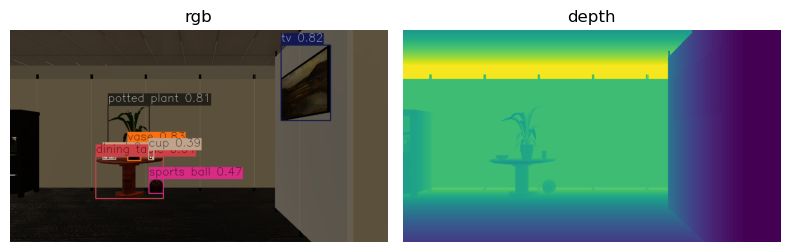

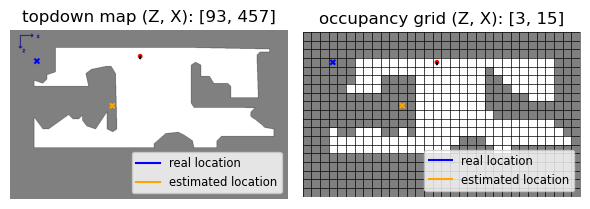


Target object <tv> not found after 1 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 3.074 m


Simulation 80/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


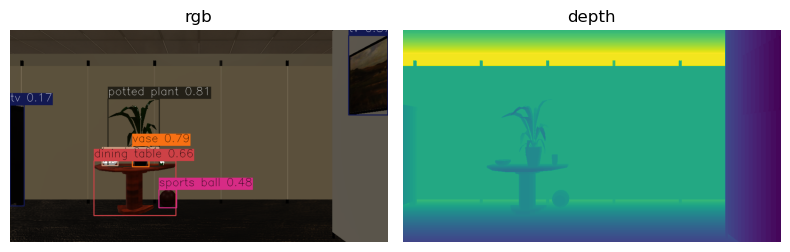

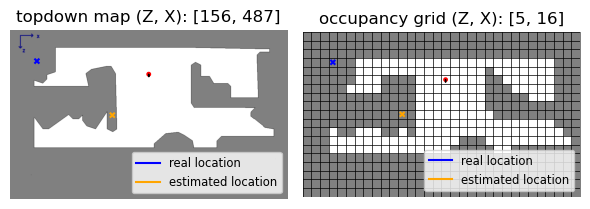


Target object <tv> not found after 17 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 3.37 m
Computed location error: 3.253 m


Simulation 81/100


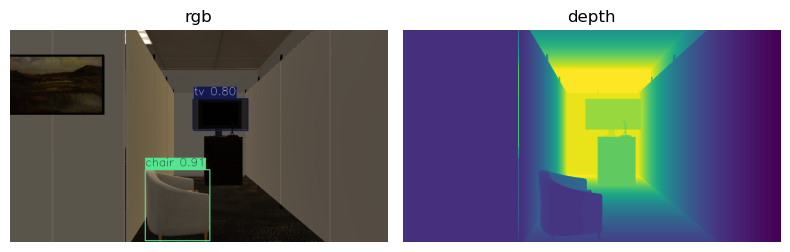

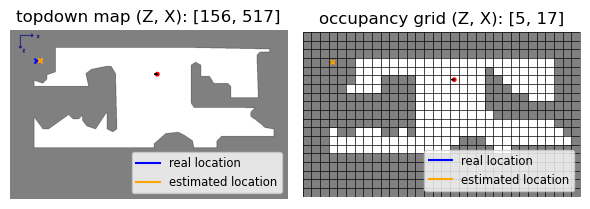


Target object <tv> found after 35 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 35
Travelled distance: 6.77 m
Computed location error: 0.121 m


Simulation 82/100


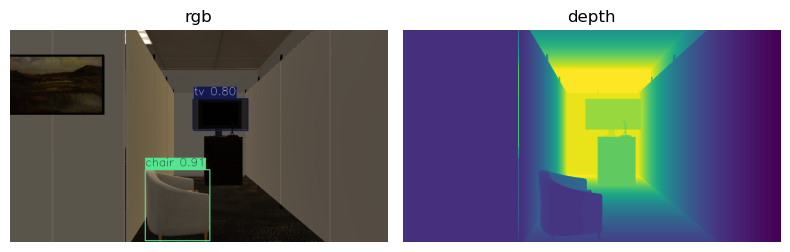

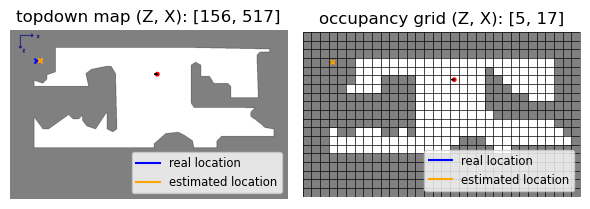


Target object <tv> found after 34 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 34
Travelled distance: 6.46 m
Computed location error: 0.121 m


Simulation 83/100


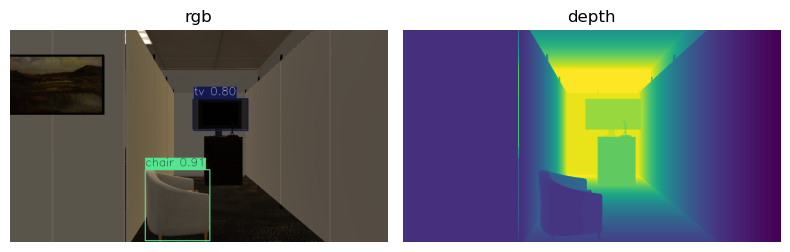

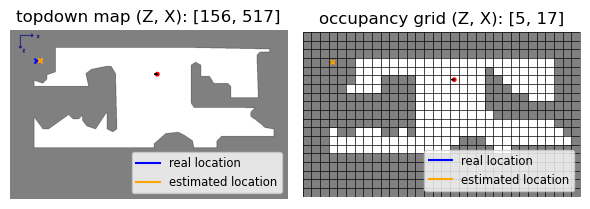


Target object <tv> found after 13 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 13
Travelled distance: 2.18 m
Computed location error: 0.121 m


Simulation 84/100


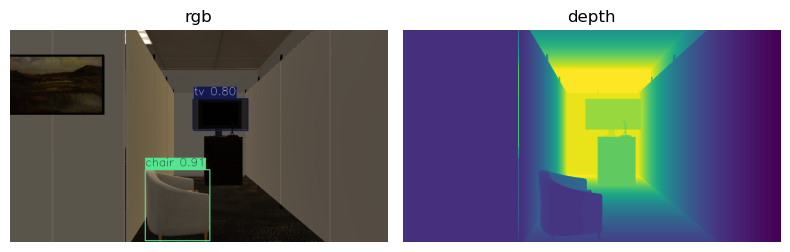

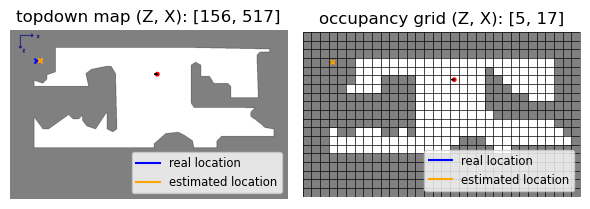


Target object <tv> found after 9 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 9
Travelled distance: 1.24 m
Computed location error: 0.121 m


Simulation 85/100


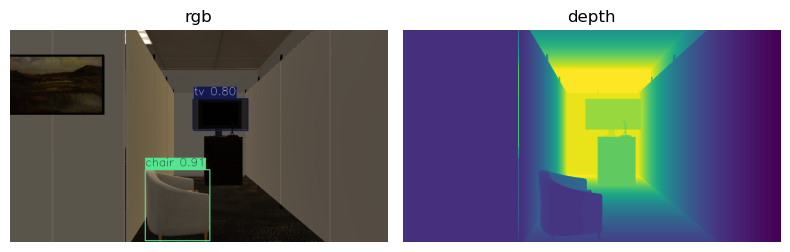

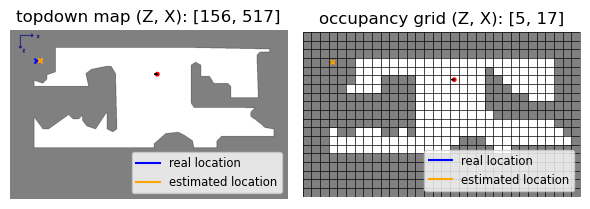


Target object <tv> found after 16 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 3.10 m
Computed location error: 0.121 m


Simulation 86/100


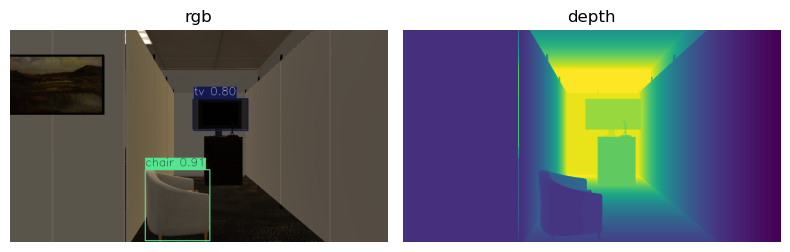

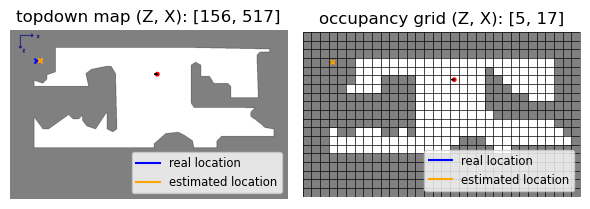


Target object <tv> found after 18 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 18
Travelled distance: 2.50 m
Computed location error: 0.121 m


Simulation 87/100


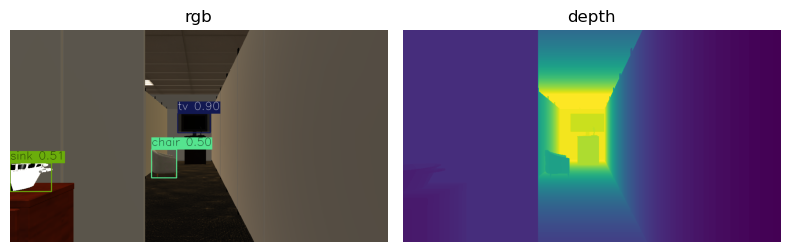

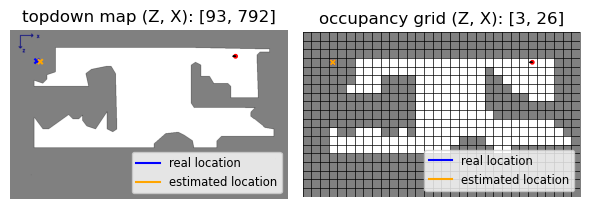


Target object <tv> found after 15 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 15
Travelled distance: 2.50 m
Computed location error: 0.122 m


Simulation 88/100


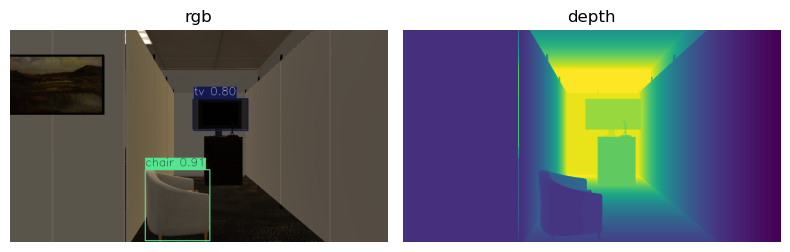

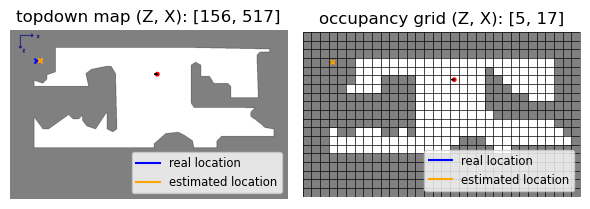


Target object <tv> found after 35 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 35
Travelled distance: 6.17 m
Computed location error: 0.121 m


Simulation 89/100


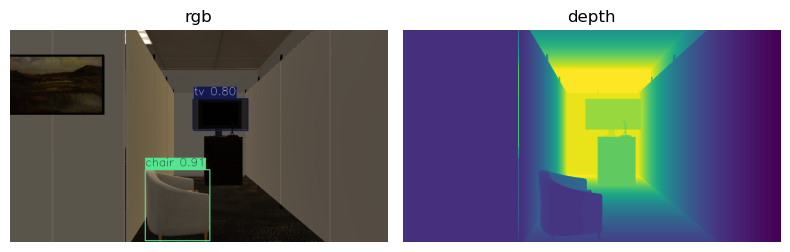

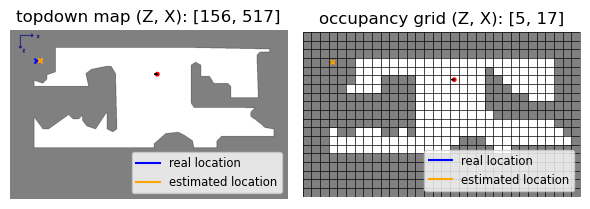


Target object <tv> found after 14 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 14
Travelled distance: 2.18 m
Computed location error: 0.121 m


Simulation 90/100


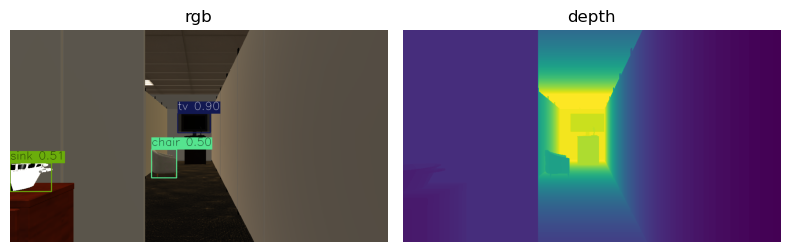

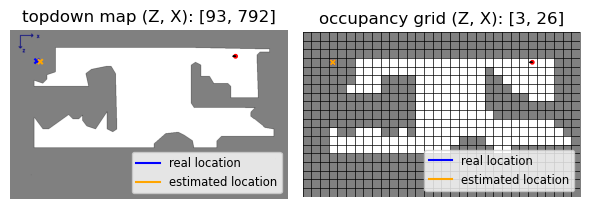


Target object <tv> found after 11 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 11
Travelled distance: 1.57 m
Computed location error: 0.122 m


Simulation 91/100

Location error 3.253 m exceeds threshold 0.5 m. FAILURE!


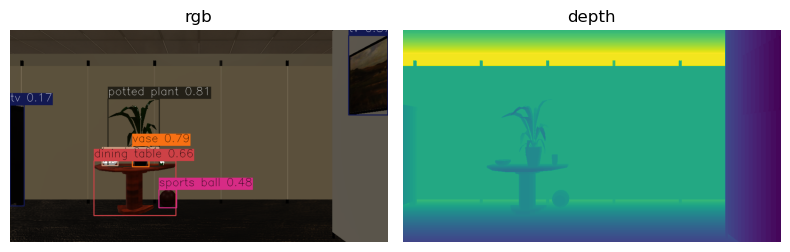

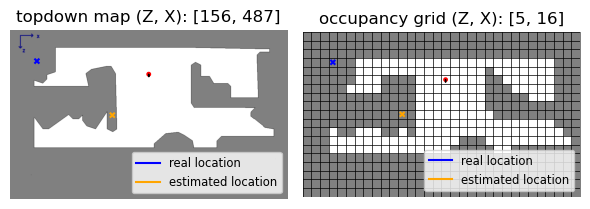


Target object <tv> not found after 17 actions!
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 17
Travelled distance: 3.07 m
Computed location error: 3.253 m


Simulation 92/100


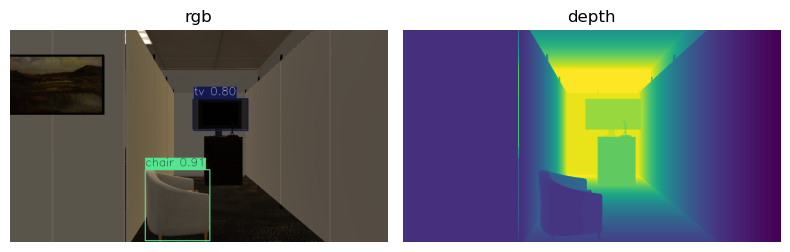

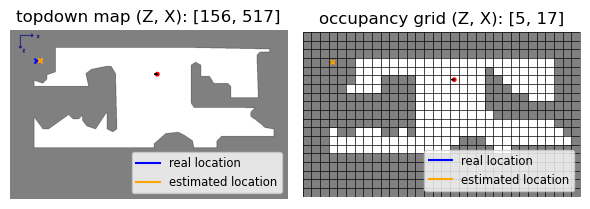


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 2.80 m
Computed location error: 0.121 m


Simulation 93/100


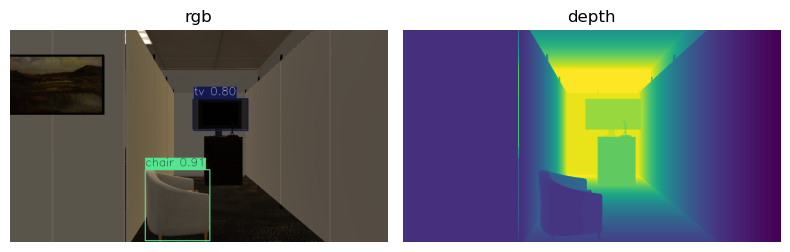

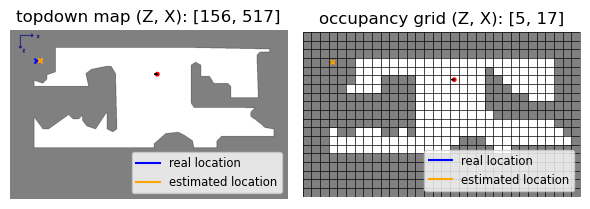


Target object <tv> found after 20 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 20
Travelled distance: 3.71 m
Computed location error: 0.121 m


Simulation 94/100


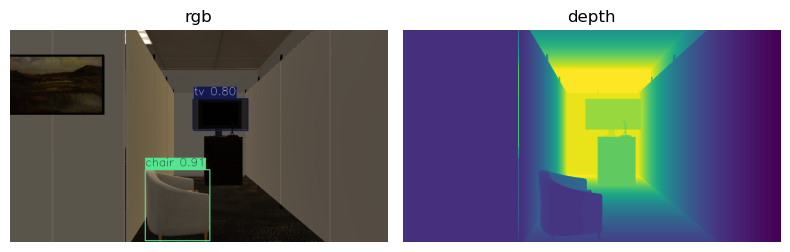

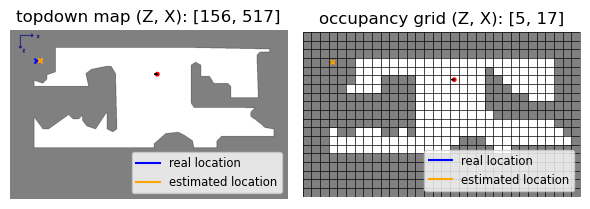


Target object <tv> found after 16 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 2.51 m
Computed location error: 0.121 m


Simulation 95/100


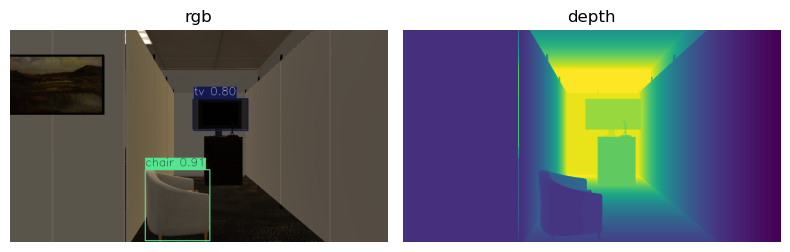

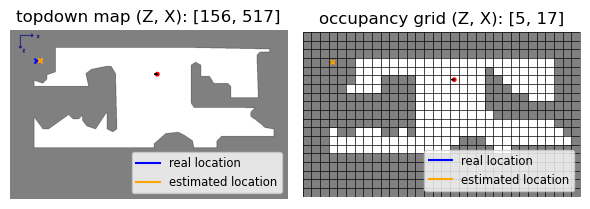


Target object <tv> found after 34 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 34
Travelled distance: 6.46 m
Computed location error: 0.121 m


Simulation 96/100


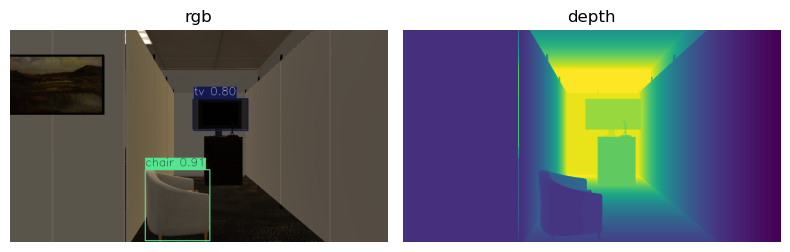

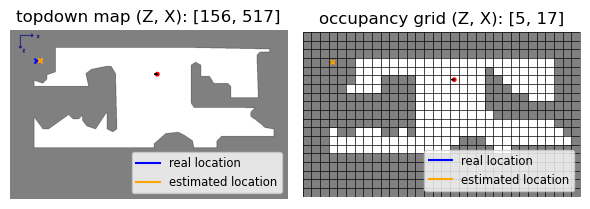


Target object <tv> found after 9 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 9
Travelled distance: 1.23 m
Computed location error: 0.121 m


Simulation 97/100


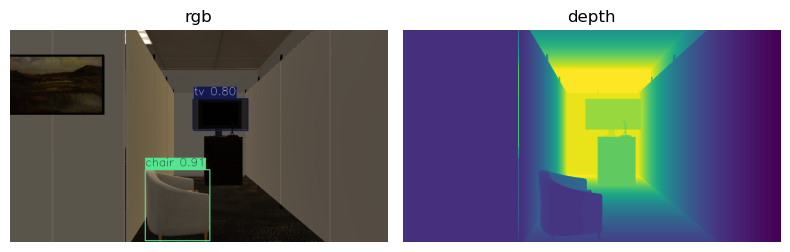

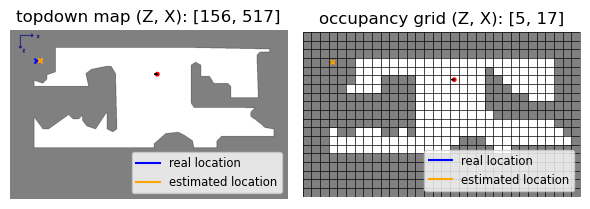


Target object <tv> found after 5 actions!
Found location: [    -9.3765    -0.45808     -4.2602]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 5
Travelled distance: 0.31 m
Computed location error: 0.121 m


Simulation 98/100


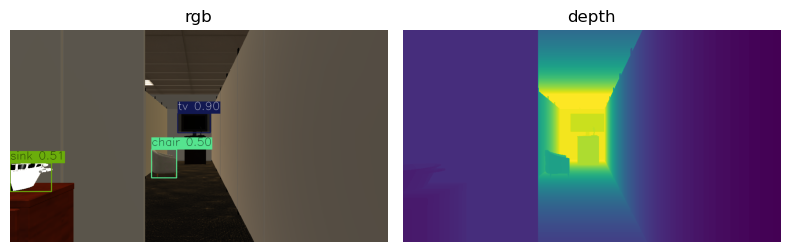

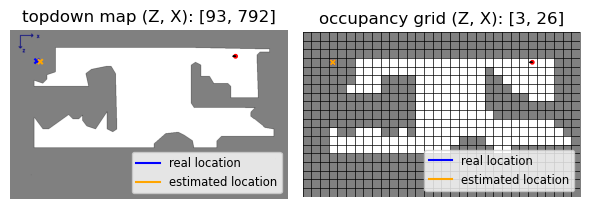


Target object <tv> found after 9 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 9
Travelled distance: 1.25 m
Computed location error: 0.122 m


Simulation 99/100


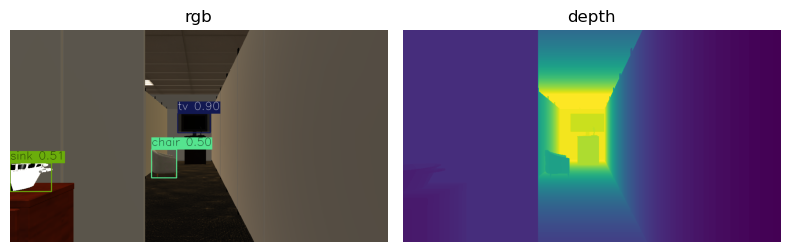

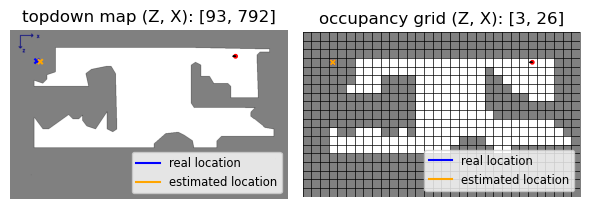


Target object <tv> found after 16 actions!
Found location: [    -9.3765    -0.45553     -4.2248]
Ground-truth location: [-9.496637344360352, 1.4597948789596558, -4.243052005767822]
Number of actions: 16
Travelled distance: 2.81 m
Computed location error: 0.122 m


In [7]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Get initial observations and maps
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]
    
    # Display the initial simulation state (maps + observations)
    print(f"\n\nSimulation {index}/{len(starting_grid_positions)}")

    # Metrics initialization
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

    # Main simulation loop
    while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
        
        # Cluster map
        cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
        cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
        cluster_centers_copy = cluster_centers.copy() # For displaying logic

        # Go through each cluster center
        while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

            # Select closest cluster center
            cluster_center, path = simtools.get_closest_cluster_path(grid_position, cluster_centers, grid_free_cells)
            #print(f"Next cluster: {cluster_center} Path: {path} Distance: {CELL_SIDE * len(path)} m")

            # Move along the path 
            while (path) and (num_actions < MAX_ITER) and (not target_found):
                
                # Compute actions to move to next path cell
                action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

                # Go through each action in the action list
                for action in action_list:
                    # Perform action
                    grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                    idx = grid_free_cells.index(grid_position)
                    map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                    agent_positions = (map_position, grid_position)
                    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                    # Update metrics
                    num_actions += 1
                    travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                    # Update agent state
                    agent_state.position = world_position
                    agent_state.rotation = agent_quart
                    agent.set_state(agent_state)

                    # Get observations
                    obs = sim.get_sensor_observations(0)
                    rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                    # YOLO Prediction
                    results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                    detections = simtools.parse_yolo_detections(results)
                    simtools.merge_rgb_yolo_outputs(rgb, detections)
                    target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

                    # Check if target was found
                    if target_found: break

                # Remove the path cell from the path
                path.pop(0)

            # Check if the target was found
            if target_found: break

            # Rotate times to get the full 360 degrees view
            for i in range(3):
                # Perform the action
                grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1

                # Get observations
                obs = sim.get_sensor_observations(0)
                rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                
                # If the target object is found, break
                if target_found: break 

            # Remove the grid cluster center from the list
            cluster_centers.remove(cluster_center)

        # Double the number of clusters
        num_clusters *= 2

    # Compute the target location if it was found
    if target_found:
        # Real world position
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Append metrics to epochs
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)

In [ ]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    



METRICS:

Total number of epochs: 100
Number of successful epochs: 85
Success rate: 85.00%
Average number of actions (epochs): 17.81
Average travelled distance (epochs): 3.06 m
Average success rate (epochs): 85.00%

Average number of actions (successful epochs): 18.12
Average travelled distance (successful epochs): 3.09 m
Average location error (successful epochs): 0.121 m

Max number of actions (epochs): 36
Min number of actions (epochs): 1
Std number of actions (epochs): 9.318470904606613


In [9]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")


Metrics saved to results/metrics.json


In [10]:
sim.close()  # Close the simulator